# Import library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
import os
import warnings
import textwrap
warnings.filterwarnings('ignore')

# Statistical Analysis
from scipy.stats import mannwhitneyu, ks_2samp, chi2_contingency

# Machine Learning Library
import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, recall_score, roc_curve,
                             brier_score_loss, confusion_matrix, precision_score, log_loss)
from sklearn.metrics import precision_recall_curve, auc as auc_calculations
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV

# Imbalance data
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Create churn evalution framework
from dataclasses import dataclass
from collections import defaultdict

# Configure parameter
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Runtime confirmation
FAST_RUN = True   # Set to False for full run with extensive computations

print("All libraries imported successfully!")
print("Ready for data analysis and machine learning tasks.")
print(f"Fast run is {'Enabled' if FAST_RUN else 'disabled'}")
print("RANDOM_STATE set to:", RANDOM_STATE)

All libraries imported successfully!
Ready for data analysis and machine learning tasks.
Fast run is Enabled
RANDOM_STATE set to: 42


# EDA - Exploratory Data Analysis

**1. Load data**

In [2]:
# Load dataset
print("=" * 10, "DATA OVERVIEW", "=" * 10)

DATA_DIR = "/content/drive/MyDrive/Viettel Dataset Customers/Dataset"
print("List of data:", os.listdir(DATA_DIR))

# Read metadata and main dataset
sheets_path = os.path.join(DATA_DIR, "Danh_sach_truong_bai_1.xlsx")
txt_path = os.path.join(DATA_DIR, "junction_postvip_sum_6mon_enr.txt")

sheets_columns = pd.read_excel(sheets_path)
df_full = pd.read_csv(txt_path, sep='|', header=None)

# Match column between TXT and XLSX file
column_names = sheets_columns["Features"].tolist()
df_full.columns = column_names

# Data information
print(f"\nDataset shape: {df_full.shape}")
memory_usage = df_full.memory_usage(deep=True).sum() / (1024 * 1024)
print(f"Memory usage: {memory_usage:.2f} MB")
print(f"Duplicated rows: {df_full.duplicated().sum()}")

# Data types
print("\nData types of columns:")
print(df_full.dtypes.value_counts())

# Review data
print("\nFirst 5 rows of the dataset:")
display(df_full.head())

# Display column names
print(f"\nTotal number of columns: {len(df_full.columns)}")

cols_str = ", ".join(f'"{c}"' for c in df_full.columns)
wrapped = textwrap.fill(cols_str, width=230)
print(f"Columns: [{wrapped}]")

========== DATA OVERVIEW ==========
List of data: ['junction_postvip_sum_6mon_enr.txt', 'Danh_sach_truong_bai_1.xlsx']

Dataset shape: (919361, 153)
Memory usage: 1073.17 MB
Duplicated rows: 0

Data types of columns:
float64    150
int64        3
Name: count, dtype: int64

First 5 rows of the dataset:


,ID,sum_total_use_charge_tn,sum_total_use_charge_tn_1,sum_total_use_charge_tn_2,sum_total_use_charge_tn_3,sum_total_use_charge_tn_4,sum_total_use_charge_tn_5,sum_total_A s_tn,sum_total_A s_tn_1,sum_total_A s_tn_2,...,sum_M_times_tn_3,sum_M_times_tn_4,sum_M_times_tn_5,sum_M_charge_tn,sum_M_charge_tn_1,sum_M_charge_tn_2,sum_M_charge_tn_3,sum_M_charge_tn_4,sum_M_charge_tn_5,churn
0,2285899345,349688.56,400264.96,366640.87,464489.95,387936.79,364476.79,559.0,682.0,601.0,...,242.0,198.0,178.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,2293856355,195987.11,224965.55,182741.57,206699.93,180660.21,183674.34,712.0,857.0,374.0,...,336.0,169.0,138.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,2290588355,316340.62,322837.18,248428.44,240993.57,224259.06,207918.73,2021.0,1773.0,1205.0,...,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,2216952365,181012.38,175681.86,233540.52,155115.52,152377.36,156420.10,290.0,246.0,252.0,...,25.0,33.0,78.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,2221641375,334968.69,434120.10,253201.41,199496.40,126333.27,102412.77,1671.0,1717.0,1255.0,...,169.0,275.0,188.0,0.0,0.0,0.0,0.0,0.0,0.0,0



Total number of columns: 153
Columns: ["ID", "sum_total_use_charge_tn", "sum_total_use_charge_tn_1", "sum_total_use_charge_tn_2", "sum_total_use_charge_tn_3", "sum_total_use_charge_tn_4", "sum_total_use_charge_tn_5", "sum_total_A s_tn", "sum_total_A s_tn_1",
"sum_total_A s_tn_2", "sum_total_A s_tn_3", "sum_total_A s_tn_4", "sum_total_A s_tn_5", "sum_free_service_fee_tn", "sum_free_service_fee_tn_1", "sum_free_service_fee_tn_2", "sum_free_service_fee_tn_3", "sum_free_service_fee_tn_4",
"sum_free_service_fee_tn_5", "sum_t_A_charge_tn", "sum_t_A_charge_tn_1", "sum_t_A_charge_tn_2", "sum_t_A_charge_tn_3", "sum_t_A_charge_tn_4", "sum_t_A_charge_tn_5", "sum_t_dịch vụ B_charge_tn", "sum_t_dịch vụ B_charge_tn_1",
"sum_t_dịch vụ B_charge_tn_2", "sum_t_dịch vụ B_charge_tn_3", "sum_t_dịch vụ B_charge_tn_4", "sum_t_dịch vụ B_charge_tn_5", "sum_t_dịch vụ B_times_tn", "sum_t_dịch vụ B_times_tn_1", "sum_t_dịch vụ B_times_tn_2", "sum_t_dịch vụ
B_times_tn_3", "sum_t_dịch vụ B_times_tn_4", "sum_t_dịch 

**2. Data Survey**

In [3]:
print("=" * 10, "TARGET VARIABLES SURVEYS", "=" * 10)

target_columns = "churn"
target_loc = df_full[target_columns]

# Target variables analysis (Churn = 1, No churn = 0)
target_loc["churn_percentage"] = (df_full[target_columns] == 1).astype(int)
target_counts = target_loc["churn_percentage"].value_counts()

if 1 in target_counts.index:
    churn_rate = (target_counts[1] / (target_counts[0] + target_counts[1]))
else:
    churn_rate = 0.0
    print("No churned customers found in the dataset.")

print("Target variables:", target_columns)
print("Churn Distribution: ")
print(target_counts)
print(f"Overall Churn Rate: {churn_rate:.4f} ({churn_rate * 100:.2f}%)")

========== TARGET VARIABLES SURVEYS ==========
Target variables: churn
Churn Distribution: 
churn
0    895884
1     23477
Name: count, dtype: int64
Overall Churn Rate: 0.0255 (2.55%)


In [4]:
print("=" * 10, "DATA QUALITY SUMMARY", "=" * 10)

# Missing values analysis in dataset
summary = pd.DataFrame({
    "Data Type": df_full.dtypes,
    "Non-Null Count": df_full.notnull().sum(),
    "Missing_count" : df_full.isnull().sum(),
    "Missing_percentage" : (df_full.isnull().sum() / len(df_full) * 100).round(2),
    "Unique Values": df_full.nunique()
})

print("Missing values summary:")
check_cols = summary[summary["Missing_percentage"] > 0]
if len(check_cols) > 0:
  print(check_cols.head(20))
else:
  print("No missing values")

# Add zero counts (only for numeric)
numeric_cols = df_full.select_dtypes(include=[np.number]).columns
zero_counts = {col: (df_full[col] == 0.0).sum() if col in numeric_cols else np.nan for col in df_full.columns}
summary["Zero Count"] = pd.Series(zero_counts)
summary["Zero %"] = round(summary["Zero Count"] / len(df_full) * 100, 2)

# Identify constant columns
summary["Is Constant"] = summary["Unique Values"] == 1

# Sort by Missing % for easier reading
summary = summary.sort_values(by="Missing_percentage", ascending=False)
display(summary.head(10))

total_missing = df_full.isnull().sum().sum() # Sum the Series to get a single value
total_percent = (total_missing / df_full.size) * 100 # Calculate the overall percentage
print(f"\n🔍 Total missing cells: {total_missing:,} ({total_percent:.2f}% of all data)")
print("=" * 10, "DATA QUALITY CHECK COMPLETED", "=" * 10)

========== DATA QUALITY SUMMARY ==========
Missing values summary:
No missing values


,Data Type,Non-Null Count,Missing_count,Missing_percentage,Unique Values,Zero Count,Zero %,Is Constant
ID,int64,919361,0,0.0,919361,0,0.00,False
sum_total_use_charge_tn,float64,919361,0,0.0,808347,18472,2.01,False
sum_total_use_charge_tn_1,float64,919361,0,0.0,812388,12956,1.41,False
sum_total_use_charge_tn_2,float64,919361,0,0.0,815655,12768,1.39,False
sum_total_use_charge_tn_3,float64,919361,0,0.0,816908,12787,1.39,False
sum_total_use_charge_tn_4,float64,919361,0,0.0,812859,13393,1.46,False
sum_total_use_charge_tn_5,float64,919361,0,0.0,816530,14790,1.61,False
sum_total_A s_tn,float64,919361,0,0.0,5462,11626,1.26,False
sum_total_A s_tn_1,float64,919361,0,0.0,5367,6242,0.68,False
sum_total_A s_tn_2,float64,919361,0,0.0,5318,6076,0.66,False



🔍 Total missing cells: 0 (0.00% of all data)
========== DATA QUALITY CHECK COMPLETED ==========


# Feature Categorization

In [5]:
# Feature Categorization and Selection
print("=" * 10, "FEATURE CATEGORIZATION", "=" * 10)

# Define feature group based on business logic
feature_groups = {
    "ID": [], "Demographic": [], "Usage": [], "Charge": [], "Volume": [],
    "Times": [], "Duration": [], "Temporal": [], "Target": [], "Other": []
}

# Categorize each columnns based on its name
for cols in df_full.columns.tolist():
  name = cols.lower()
  if "id" in name:
      feature_groups["ID"].append(cols)
  elif "age" in name or "gender" in name or "province" in name:
      feature_groups["Demographic"].append(cols)
  elif "use" in name or "usage" in name or "total" in name:
      feature_groups["Usage"].append(cols)
  elif "charge" in name or "fee" in name:
      feature_groups["Charge"].append(cols)
  elif "volume" in name:
      feature_groups["Volume"].append(cols)
  elif "time" in name or "times" in name:
      feature_groups["Times"].append(cols)
  elif "duration" in name:
      feature_groups["Duration"].append(cols)
  elif "churn" in name:
      feature_groups["Target"].append(cols)
  else:
      feature_groups["Other"].append(cols)
      print(f"Unclassified features: {cols}")

# Summary and display
total_features = 0
summary_data = []

for group_name, features in feature_groups.items():
    count = len(features)
    total_features += count

    # Add quotes around each feature name
    formatted_feature = [f"'{feature}'" for feature in features]

    # Display formatted summary neatly
    print(f"\n{group_name.upper()} ({count}/{count}):")
    if count > 0:
        print(f"Available: [{textwrap.fill(', '.join(formatted_feature), width = 200)}]")
    else:
        print("(No features in this group)")

    summary_data.append({
        "Feature Group": group_name,
        "Feature Count": count
    })

df_summary = pd.DataFrame(summary_data)

print(f"\nTotal features categorized: {total_features}")
display(print(df_summary))

========== FEATURE CATEGORIZATION ==========

ID (1/1):
Available: ['ID']

DEMOGRAPHIC (1/1):
Available: ['customer_age']

USAGE (18/18):
Available: ['sum_total_use_charge_tn', 'sum_total_use_charge_tn_1', 'sum_total_use_charge_tn_2', 'sum_total_use_charge_tn_3', 'sum_total_use_charge_tn_4', 'sum_total_use_charge_tn_5', 'sum_total_A s_tn',
'sum_total_A s_tn_1', 'sum_total_A s_tn_2', 'sum_total_A s_tn_3', 'sum_total_A s_tn_4', 'sum_total_A s_tn_5', 'sum_total_use_A s_tn', 'sum_total_use_A s_tn_1', 'sum_total_use_A s_tn_2',
'sum_total_use_A s_tn_3', 'sum_total_use_A s_tn_4', 'sum_total_use_A s_tn_5']

CHARGE (60/60):
Available: ['sum_free_service_fee_tn', 'sum_free_service_fee_tn_1', 'sum_free_service_fee_tn_2', 'sum_free_service_fee_tn_3', 'sum_free_service_fee_tn_4', 'sum_free_service_fee_tn_5', 'sum_t_A_charge_tn',
'sum_t_A_charge_tn_1', 'sum_t_A_charge_tn_2', 'sum_t_A_charge_tn_3', 'sum_t_A_charge_tn_4', 'sum_t_A_charge_tn_5', 'sum_t_dịch vụ B_charge_tn', 'sum_t_dịch vụ B_charge_tn_1

None

# Data Validaiton

========== FEATURE CORRELATION ANALYSIS ==========
🔹 Top 15 most correlated feature pairs:
                    Feature_1                  Feature_2  Correlation
0          sum_total_A s_tn_4     sum_total_use_A s_tn_4     0.999999
1          sum_total_A s_tn_3     sum_total_use_A s_tn_3     0.999999
2          sum_total_A s_tn_2     sum_total_use_A s_tn_2     0.999999
3          sum_total_A s_tn_1     sum_total_use_A s_tn_1     0.999999
4          sum_total_A s_tn_5     sum_total_use_A s_tn_5     0.999998
5            sum_total_A s_tn       sum_total_use_A s_tn     0.999998
6   sum_free_service_fee_tn_3  sum_free_service_fee_tn_4     0.992332
7      sum_total_use_A s_tn_5           sum_M_times_tn_5     0.991731
8          sum_total_A s_tn_5           sum_M_times_tn_5     0.991688
9      sum_total_use_A s_tn_4           sum_M_times_tn_4     0.990241
10         sum_total_A s_tn_4           sum_M_times_tn_4     0.990216
11     sum_total_use_A s_tn_3           sum_M_times_tn_3     0.989490

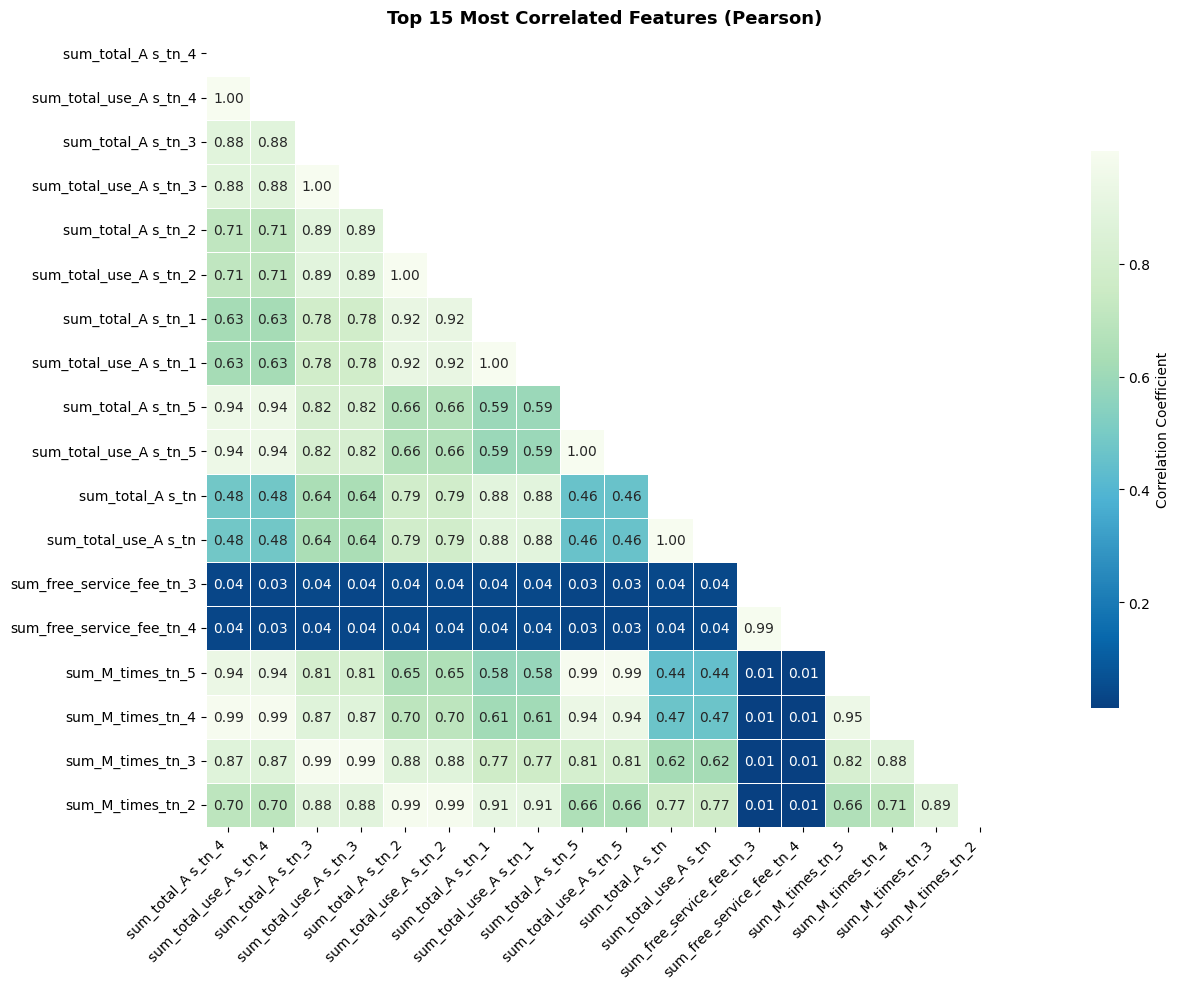

🔻 Suggested drop candidates (Correlation > 0.9):
  - sum_t_A _times_tn_5, sum_t_dịch vụ B_times_tn_5, sum_free_service_fee_tn_3, sum_E _charge_tn_4, sum_E  _times_tn_3, sum_G  _times_tn_4
  - sum_E _charge_tn_1, sum_E  _duration_tn_2, sum_F _times_tn_3, sum_E _charge_tn_3, sum_t_A_charge_tn_1, sum_G _charge_tn_5
  - sum_F _charge_tn_3, sum_t_dịch vụ B_times_tn, sum_total_use_A s_tn_2, sum_G _charge_tn, sum_G _charge_tn_4, sum_free_service_fee_tn_4
  - sum_D_other_charge_tn_2, sum_D_other_charge_tn_4, sum_t_dịch vụ B_times_tn_2, sum_M_times_tn_2, sum_E  _times_tn_2, sum_t_A_charge_tn_2
  - sum_G  _times_tn_2, sum_M_times_tn_3, sum_t_dịch vụ B_times_tn_1, sum_M_times_tn_1, sum_total_A s_tn_2, sum_t_A_charge_tn_3
  - sum_G _charge_tn_2, sum_free_service_fee_tn_5, sum_M_times_tn, sum_E  _duration_tn_5, sum_F _times_tn_4, sum_E  _duration_tn_4
  - sum_H_charge_tn_3, sum_G _charge_tn_1, sum_F _charge_tn_2, sum_total_use_A s_tn, sum_E  _duration_tn, sum_H_charge_tn_1
  - sum_F _charge_tn, sum

In [6]:
print("=" * 10, "FEATURE CORRELATION ANALYSIS", "=" * 10)

# Compute pearson correlation coefficients
correlations = df_full.drop(columns=["churn"], errors="ignore").corr(method="pearson").abs()

# Extract feature pairs with correlation > thresold (e.g.: 0.7)
corr_pairs = (correlations.where(np.triu(np.ones(correlations.shape), k = 1).astype(bool))
              .stack()
              .reset_index())
cum_col = [col for col in correlations.columns if col.startswith('sum_total_use_charge')]
corr_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]

# Sort correlation values descending
top_corr = corr_pairs.sort_values(by = "Correlation", ascending = False)

# Sort correlations in descending order
top_corr = corr_pairs.sort_values(by="Correlation", ascending=False).reset_index(drop=True)

# Display top correlated pairs
N = 15
print(f"🔹 Top {N} most correlated feature pairs:")
print(top_corr.head(N))

# Create a heatmap with the mask and correct aspect ratio
# Get the top correlated feature names for pivoting
selected_features = pd.unique(top_corr.head(N)[["Feature_1", "Feature_2"]].values.ravel())

# Create a sub-correlation matrix for those features
corr_subset = correlations.loc[selected_features, selected_features]

# Create a mask with the same shape as the subset
mask = np.triu(np.ones_like(corr_subset, dtype=bool))

# Plot heatmap for these top features
plt.figure(figsize=(18, 10))
sns.heatmap(
    corr_subset,
    mask=mask,
    cmap="GnBu_r",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.7, "label": "Correlation Coefficient"},
)

plt.title(f"Top {N} Most Correlated Features (Pearson)", fontsize=13, weight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Suggest dropping redundant features
threshold = 0.9
drop_candidates = set(top_corr[top_corr["Correlation"] > threshold]["Feature_2"])

print(f"🔻 Suggested drop candidates (Correlation > {threshold}):")
if drop_candidates:
  # Group features per line (e.g: 6 per line)
  items_per_line = 6
  drop_candidates_list = list(drop_candidates) # Convert set to list
  for i in range(0, len(drop_candidates_list), items_per_line):
    line = ", ".join(drop_candidates_list[i:i + items_per_line])
    print(f"  - {line}")
  print(f"Total: {len(drop_candidates)} features above {threshold}")
else:
  print("  - No strong correlations found about threshold.")

# Store top features for later use
TOP_PREDICTIVE_FEATURES = top_corr["Feature_1"].head(N).tolist()

print("=" * 10, "CORRELATION ANALYSIS COMPLETED", "=" * 10)

In [7]:
print("=" * 10, "DATA VALIDATION SUMMARY", "=" * 10)

# Perform automated data validation checks on the dataset
validation_results = {
    "Rows" : len(df_full),
    "Columns" : len(df_full.columns),
    "Missing values": df_full.isnull().sum().sum(),
    "Missing columns" : df_full.columns[df_full.isnull().any()].tolist(),
    "Constant columns": len((df_full.nunique() <= 1).tolist()),
    "Numeric columns" : len(df_full.select_dtypes(include=[np.number]).columns),
    "Categorical columns" : len(df_full.select_dtypes(include=['object']).columns)
}

# Convert the dictionary to a Series, then to a DataFrame with keys as index
print(pd.DataFrame.from_dict(validation_results, orient='index', columns=['Value']))

# Find features to remove
constants_feautres = [col for col in df_full.columns if df_full[col].nunique() <= 1]
high_missing_features = [col for col in df_full.columns if df_full[col].isnull().sum() / len(df_full) > 0.85]
correlation_features = list(drop_candidates)
features_to_remove = list(set(high_missing_features + constants_feautres + correlation_features))

print(f"\nChecking features")
print(f"Constants features: {len(constants_feautres)}")
print(f"High missing features: {len(high_missing_features)}")
print(f"Correlation features: " + str(len(correlation_features)))
print(f"Total features to remove: {len(features_to_remove)}")

# Remove the features
original_shape = df_full.shape
df = df_full.drop(columns=features_to_remove, errors = "ignore")
print(f"Shape: {original_shape} → {df.shape}")

# Create the modeling_features from the available_features
modeling_features = []
for features_list in feature_groups.values():
  modeling_features.extend(features_list)

# Remove the duplicates. These features have not survived.
modeling_features = list(dict.fromkeys(modeling_features))
modeling_features = [col for col in modeling_features if col in df.columns]

# Classify for type of data
numeric_features = [f for f in modeling_features if f in df.select_dtypes(include=[np.number]).columns]
categorical_features = [f for f in modeling_features if f in df.select_dtypes(include=['object']).columns]

# Result
print(f"\nFinal features after processing data")
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

# Save variables
remaining_features = numeric_features + categorical_features
print(f"Remaining features: {len(remaining_features)}")

========== DATA VALIDATION SUMMARY ==========
                      Value
Rows                 919361
Columns                 153
Missing values            0
Missing columns          []
Constant columns        153
Numeric columns         153
Categorical columns       0

Checking features
Constants features: 0
High missing features: 0
Correlation features: 82
Total features to remove: 82
Shape: (919361, 153) → (919361, 71)

Final features after processing data
Numeric features: 71
Categorical features: 0
Remaining features: 71


========== SKEWNESS AND KURTOSIS ANALYSIS ==========
GROUP: ID (1 features)
                 ID
count  9.193610e+05
mean   1.570801e+09
std    2.171216e+09
min    1.770004e+08
25%    7.064648e+08
50%    7.952099e+08
75%    8.696279e+08
max    9.979499e+09


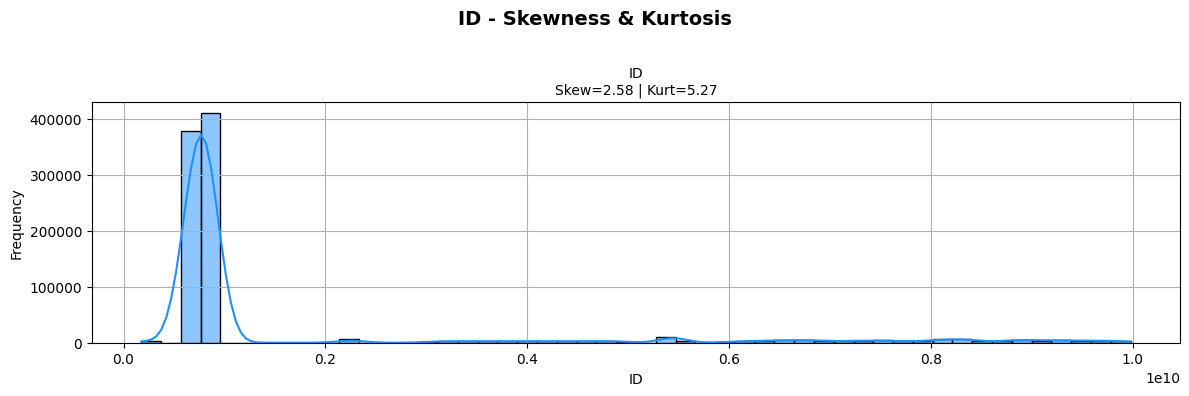

GROUP: DEMOGRAPHIC (1 features)
       customer_age
count     919361.00
mean          34.75
std            3.02
min           30.00
25%           32.00
50%           35.00
75%           37.00
max           40.00


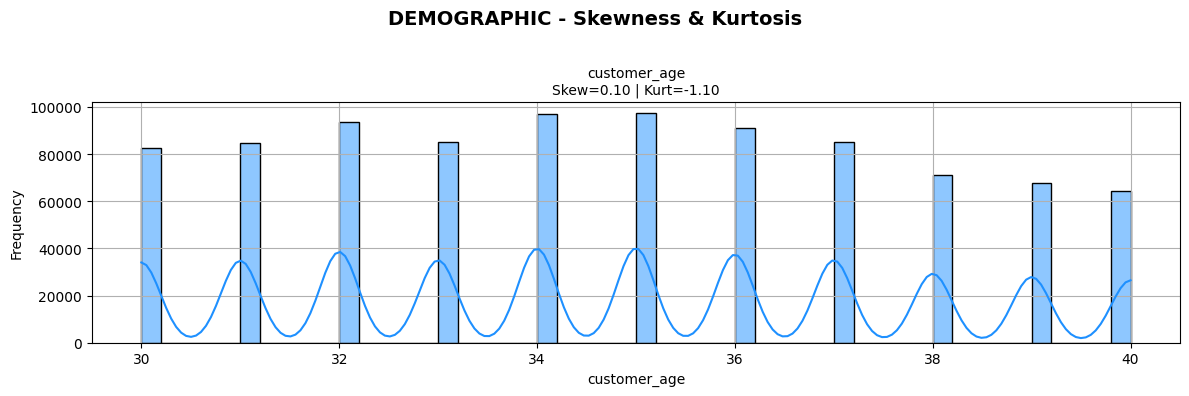

GROUP: USAGE (10 features)
       sum_total_use_charge_tn  sum_total_use_charge_tn_1  \
count                919361.00                  919361.00   
mean                 208455.04                  211684.78   
std                  210607.99                  213304.75   
min                       0.00                    -272.73   
25%                  109698.19                  111315.47   
50%                  162877.29                  165482.52   
75%                  251938.28                  254894.13   
max                99624639.30                99555007.82   

       sum_total_use_charge_tn_2  sum_total_use_charge_tn_3  \
count               9.193610e+05               9.193610e+05   
mean                2.106786e+05               2.169525e+05   
std                 2.230109e+05               2.185888e+05   
min                 0.000000e+00               0.000000e+00   
25%                 1.112850e+05               1.121504e+05   
50%                 1.650394e+05             

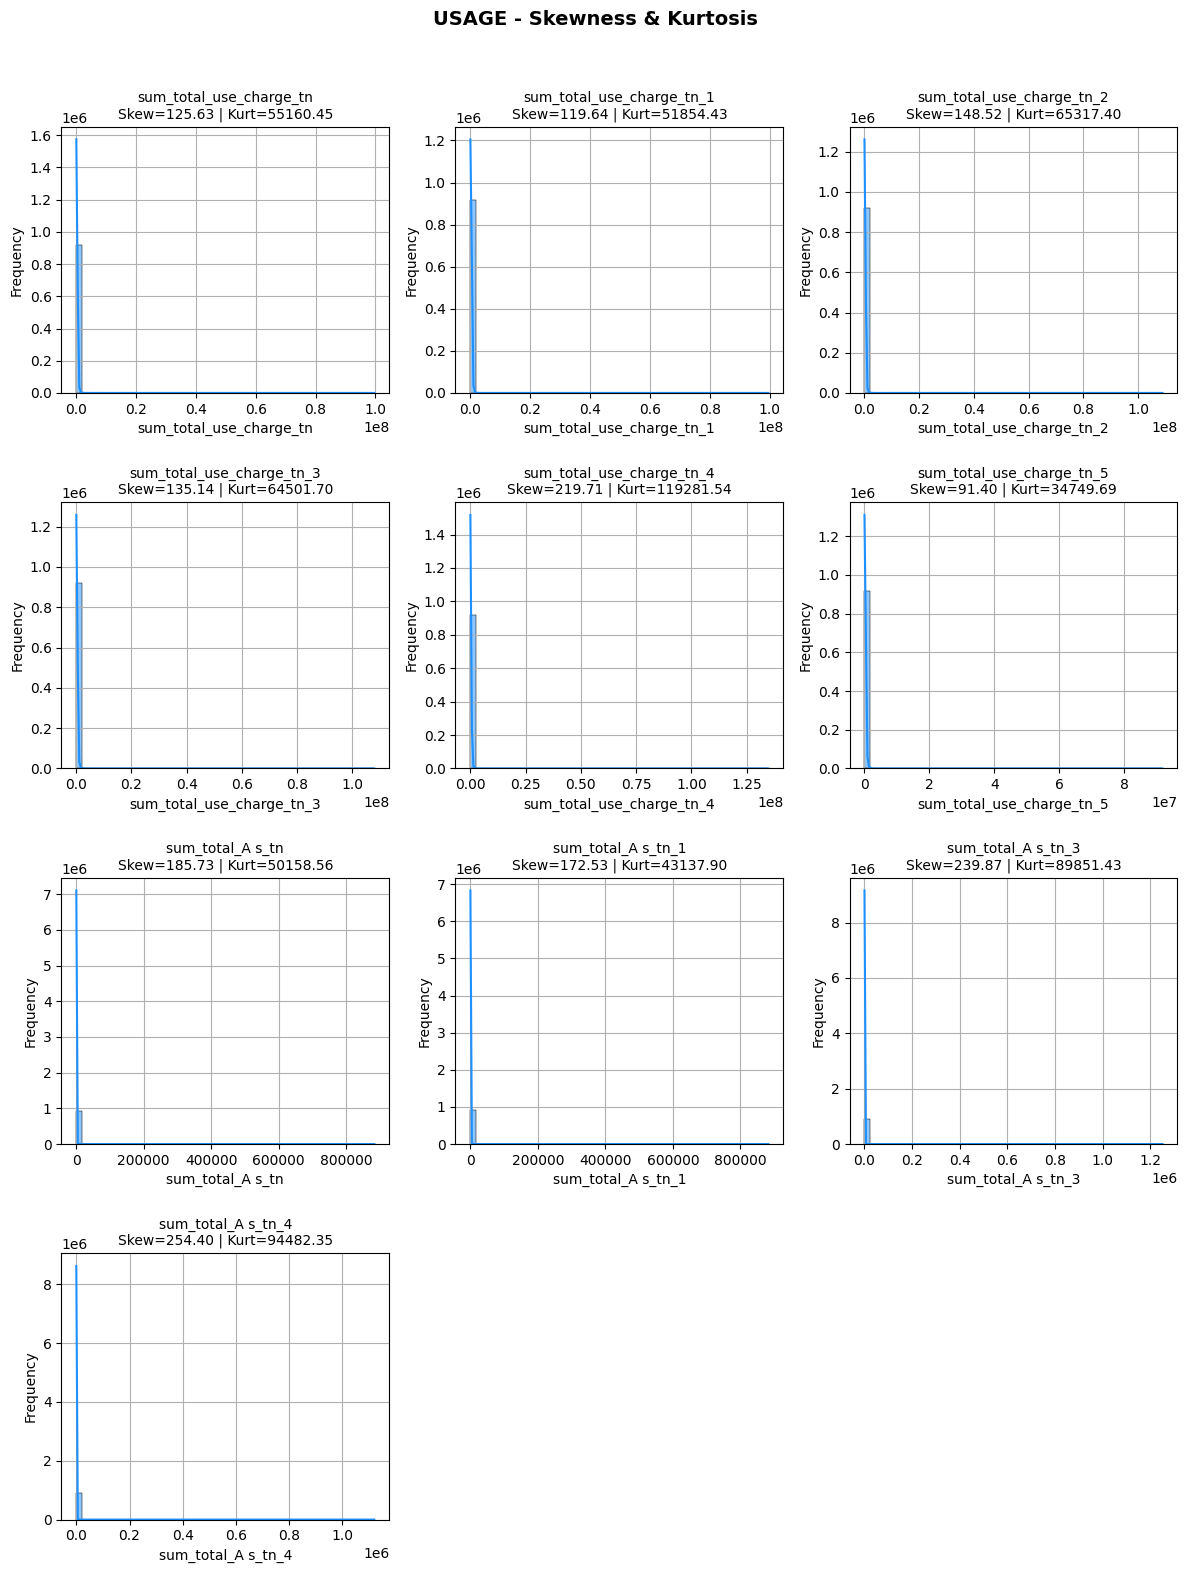

GROUP: CHARGE (25 features)
       sum_free_service_fee_tn  sum_t_A_charge_tn  sum_t_A_charge_tn_5  \
count                919361.00          919361.00            919361.00   
mean                  87035.43           59020.75             62507.99   
std                   63985.82          147373.05            146256.43   
min                       0.00               0.00                 0.00   
25%                   63636.36            5430.00              5730.00   
50%                   90909.09           23670.00             24975.00   
75%                   90909.09           68176.20             72240.00   
max                 1363636.36        99511002.93          91661808.27   

       sum_t_dịch vụ B_charge_tn  sum_t_dịch vụ B_charge_tn_1  \
count                  919361.00                    919361.00   
mean                    16480.05                     17221.80   
std                     35665.22                     36195.24   
min                     -7727.27             

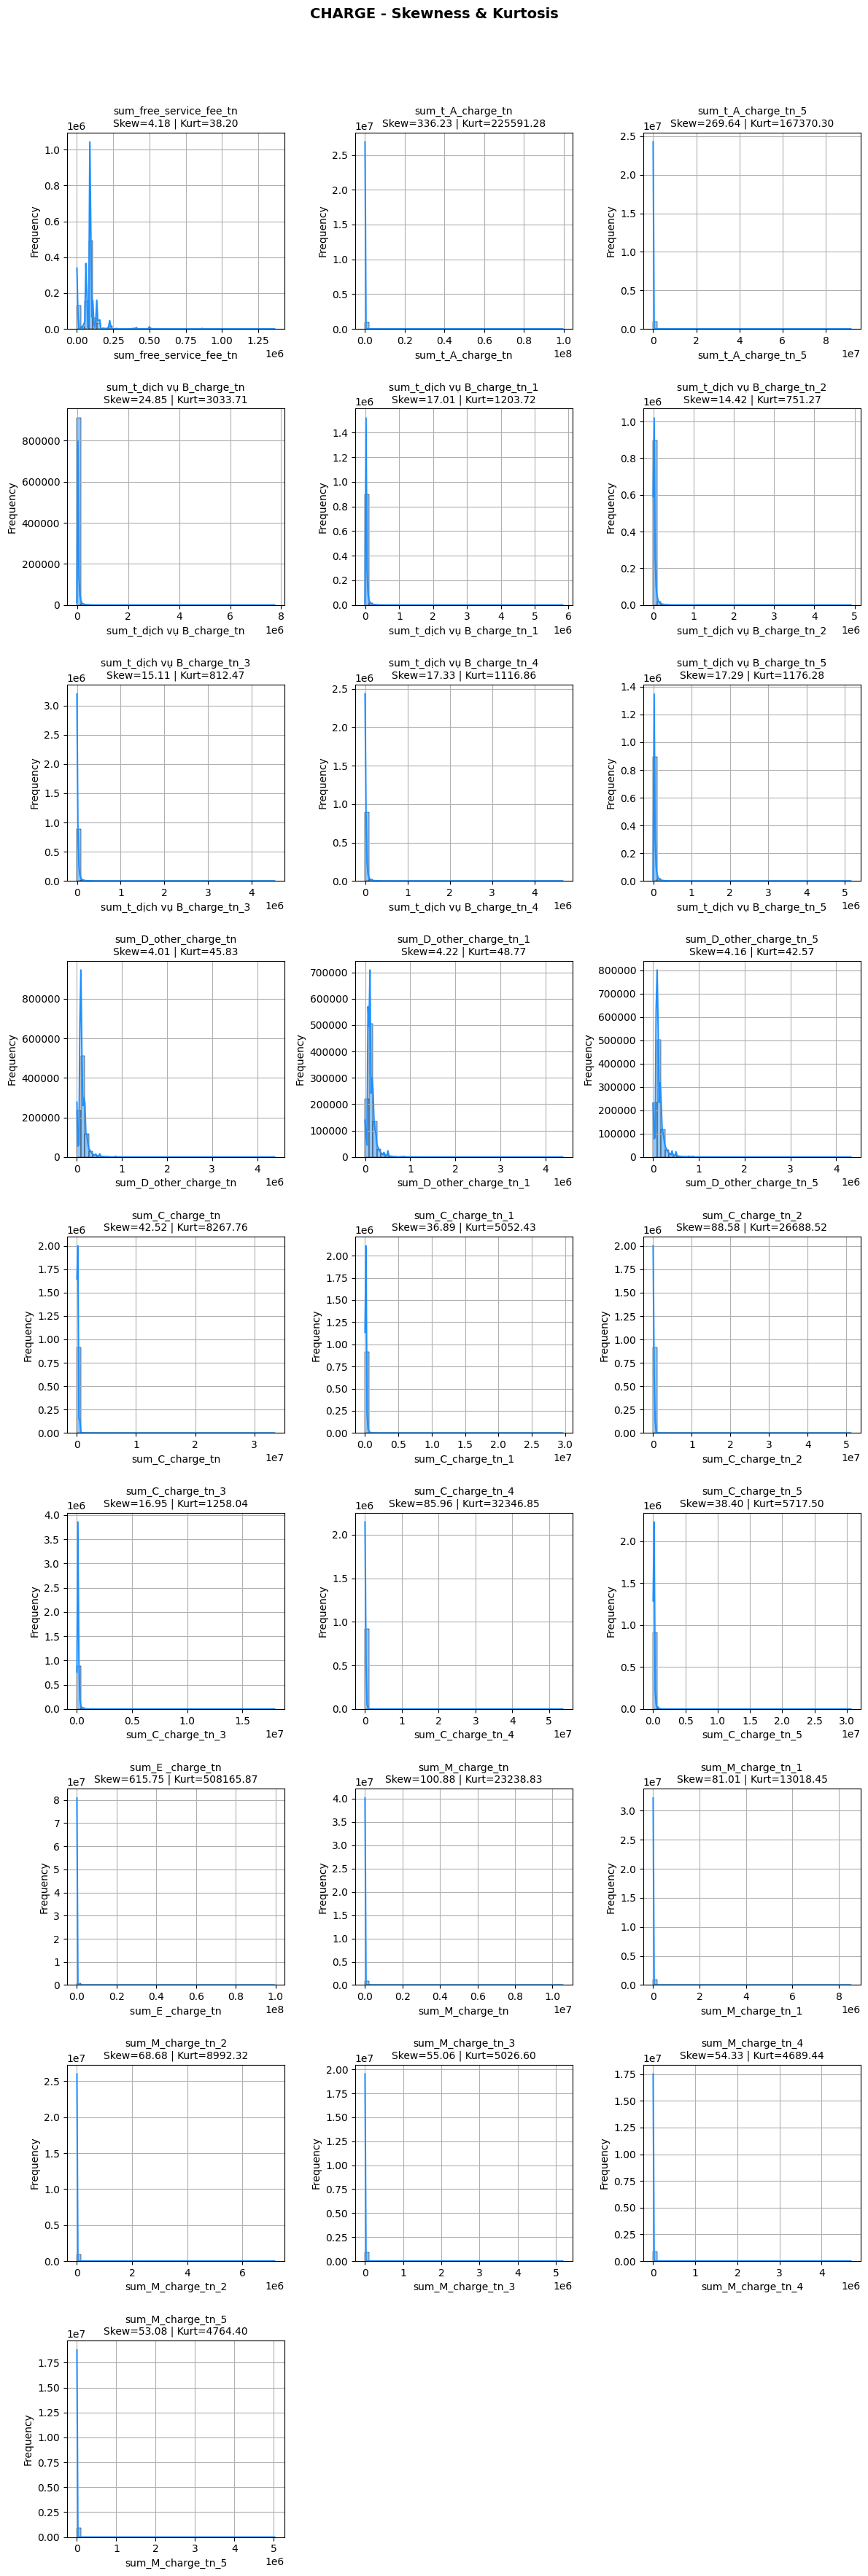

GROUP: VOLUME (6 features)
       sum_M_volume_tn  sum_M_volume_tn_1  sum_M_volume_tn_2  \
count     9.193610e+05       9.193610e+05       9.193610e+05   
mean      2.185891e+09       2.179904e+09       1.997559e+09   
std       4.342805e+09       4.370516e+09       4.017736e+09   
min       0.000000e+00       0.000000e+00       0.000000e+00   
25%       0.000000e+00       0.000000e+00       0.000000e+00   
50%       1.471606e+08       1.462659e+08       1.226604e+08   
75%       3.254381e+09       3.244874e+09       2.892323e+09   
max       2.506955e+11       2.533731e+11       2.444894e+11   

       sum_M_volume_tn_3  sum_M_volume_tn_4  sum_M_volume_tn_5  
count       9.193610e+05       9.193610e+05       9.193610e+05  
mean        1.516975e+09       1.451353e+09       1.427577e+09  
std         3.349771e+09       3.218548e+09       3.213804e+09  
min         0.000000e+00       0.000000e+00       0.000000e+00  
25%         0.000000e+00       0.000000e+00       0.000000e+00  
50%   

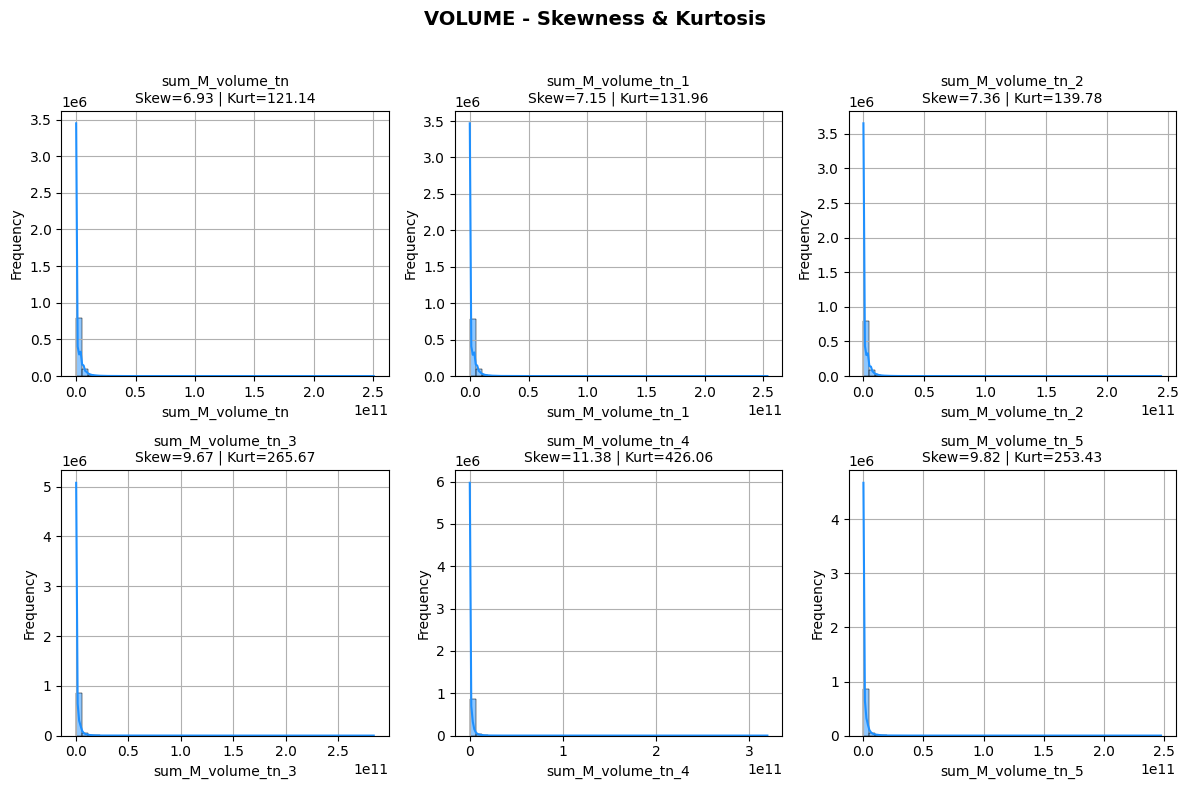

GROUP: TIMES (15 features)
       sum_t_A _times_tn  sum_C_times_tn  sum_C_times_tn_1  sum_C_times_tn_2  \
count          919361.00       919361.00         919361.00         919361.00   
mean              316.44            3.53              3.61              3.59   
std               278.40           31.59             38.28             29.95   
min                 0.00            0.00              0.00              0.00   
25%               138.00            1.00              1.00              1.00   
50%               256.00            2.00              2.00              2.00   
75%               421.00            3.00              3.00              3.00   
max             67429.00        16135.00          20664.00          15699.00   

       sum_C_times_tn_3  sum_C_times_tn_4  sum_C_times_tn_5  sum_G  _times_tn  \
count         919361.00         919361.00         919361.00         919361.00   
mean               3.49              3.45              3.47             54.06   
std      

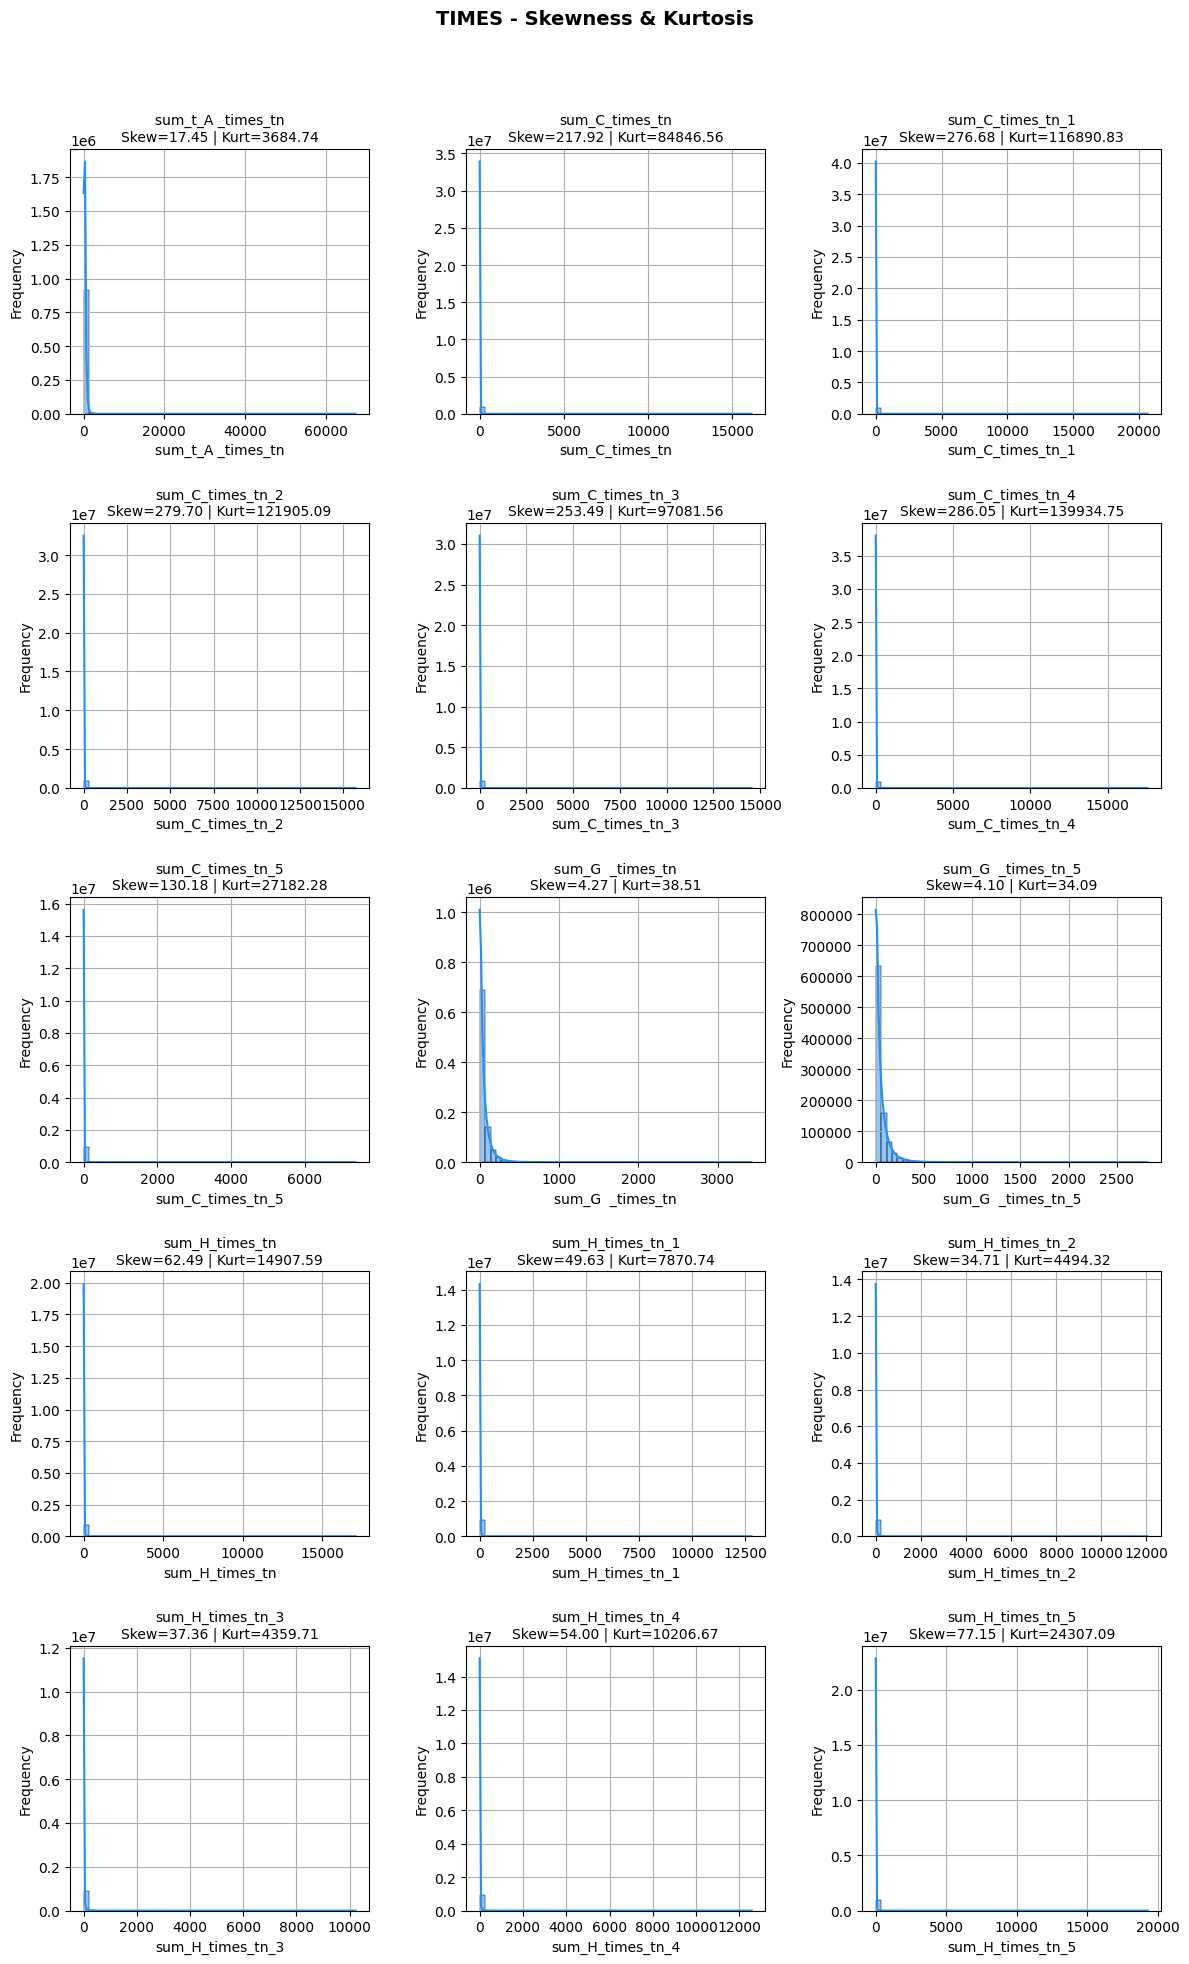

GROUP: DURATION (12 features)
       sum_t_A _duration_tn  sum_t_A _duration_tn_1  sum_t_A _duration_tn_2  \
count             919361.00               919361.00               919361.00   
mean               22237.21                22641.25                22736.28   
std                20739.19                20731.08                20901.20   
min                    0.00                    0.00                    0.00   
25%                 8717.00                 9127.00                 9298.00   
50%                17374.00                17821.00                17974.00   
75%                30586.00                31049.00                31121.00   
max              7374735.00              7372266.00              8064935.00   

       sum_t_A _duration_tn_3  sum_t_A _duration_tn_4  sum_t_A _duration_tn_5  \
count               919361.00               919361.00               919361.00   
mean                 24286.21                23500.11                23914.67   
std            

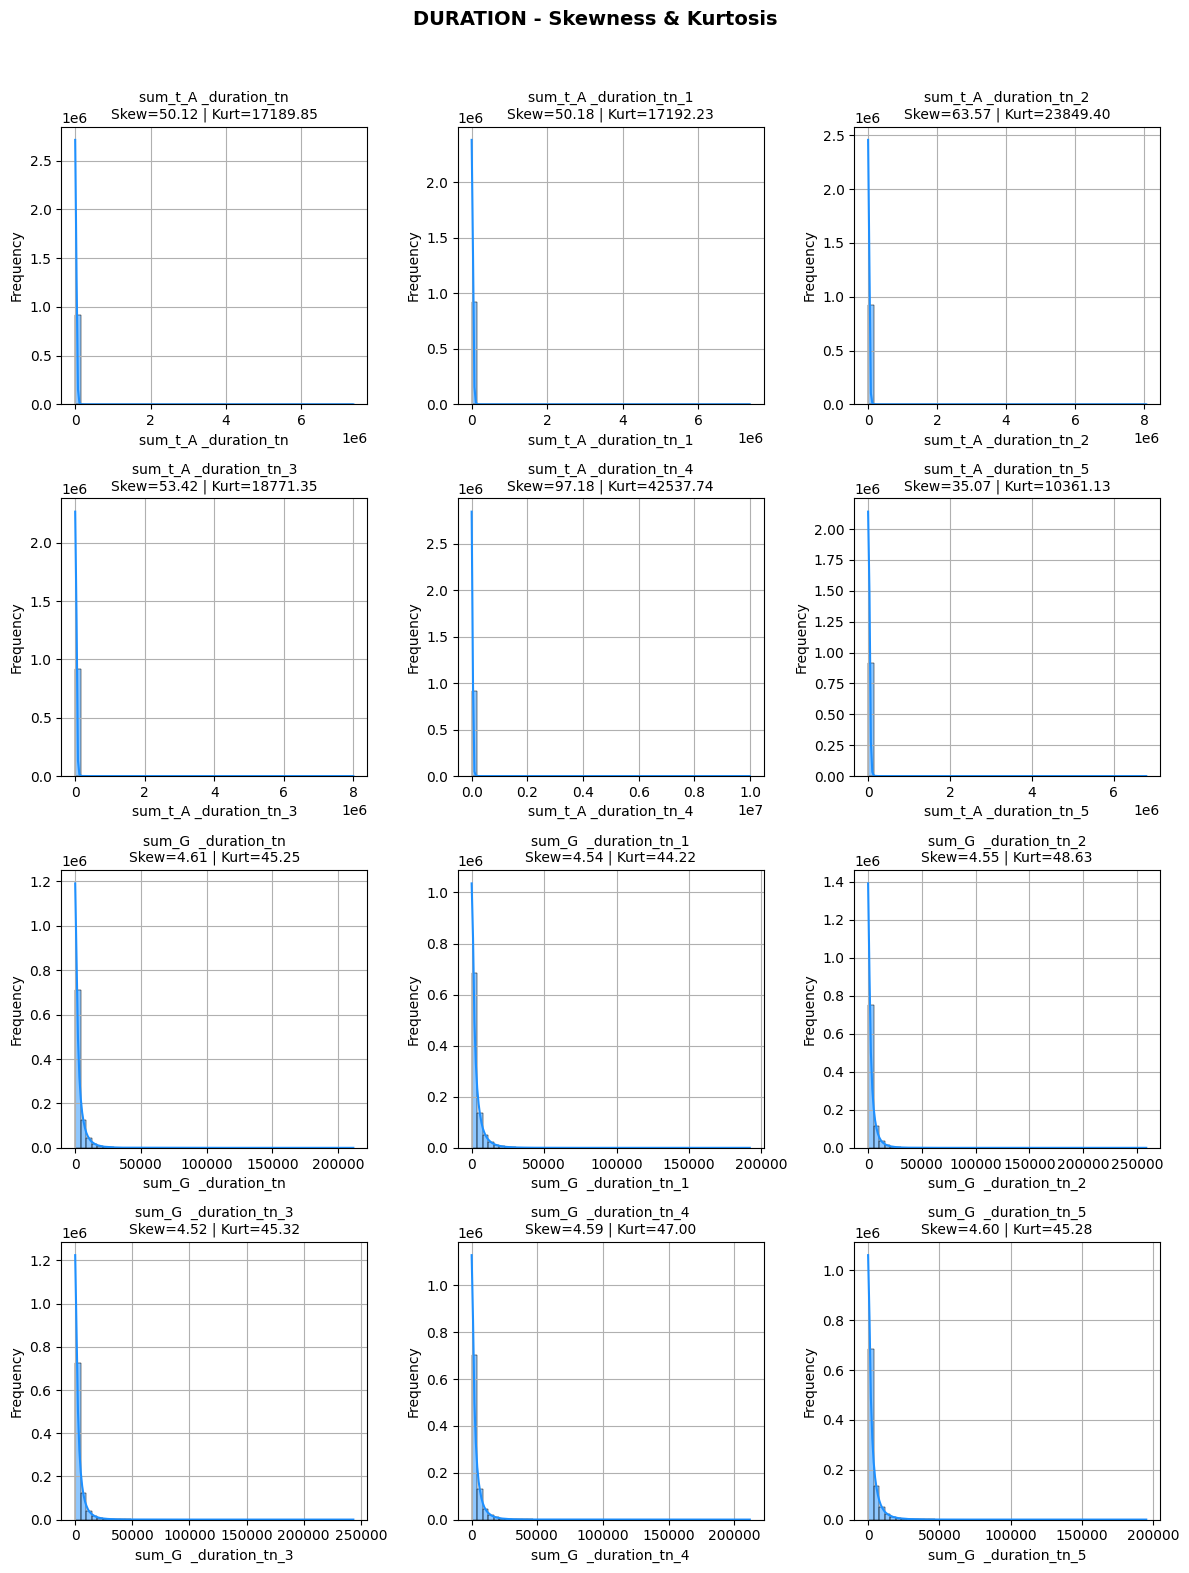

Skipping empty group: Temporal
No numeric features to describe in this group (excluding target and dropped features).
Group 'Target': no numeric features — skipped.
Skipping empty group: Other
========== SUMMARY ANALYSIS COMPLETED ==========


In [8]:
# FUNCTION 1: COMPUTE SKEWNESS AND KURTOSIS
def compute_skew_kurt(df, features, target_col, drop_candidates=None):
  """Compute skewness, kurtosis and suggest normalization scaler"""
  if drop_candidates is None:
    drop_candidates = []

  valid_features = [c for c in features if c not in drop_candidates and c != target_col]
  numeric_cols = df[valid_features].select_dtypes(include=[np.number]).columns

  if numeric_cols.empty:
      print("No numeric features to describe in this group (excluding target and dropped features).")
      return pd.DataFrame(columns=["Feature", "Skewness", "Kurtosis", "Suggested_Scaler"])

  # Compute skewness and kurtosis
  skew_kurt = pd.DataFrame({
      "Feature": numeric_cols,
      "Skewness": df[numeric_cols].skew(),
      "Kurtosis": df[numeric_cols].kurtosis()
  }).reset_index(drop=True)

  # Suggest scaler
  def normalization_summary(rows):
    skew, kurt = abs(rows["Skewness"]), abs(rows["Kurtosis"])
    if skew > 2 and kurt > 7:
      return "Log Transform"
    elif 1 < skew < 2 and 3 < kurt <= 7:
      return "RobustScaler"
    else:
      return "StandardScaler"

  skew_kurt["Suggested_Scaler"] = skew_kurt.apply(normalization_summary, axis=1)
  return skew_kurt

# FUNCTION 2: PLOT GROUP HISTOGRAMS
def plot_skew_kurt_group(df, group_name, cols, skew_kurt_summary):
  """
  Plot histograms for each numeric feature in the group
  Automatically hides empty subplots
  """
  # Filter group columns to only include those present in the skew_kurt_summary
  group_cols = [c for c in cols if c in skew_kurt_summary["Feature"].values]
  if not group_cols:
    print(f"Group '{group_name}': no numeric features \u2014 skipped.")
    return

  print(f"GROUP: {group_name.upper()} ({len(group_cols)} features)")
  print(df[group_cols].describe().round(2)) # Changed numeric_cols to group_cols

  n_features = len(group_cols)
  if n_features > 0:
    n_cols = min(3, n_features)
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize = (12, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(group_cols):
      ax = axes[i]
      sns.histplot(df[col], kde=True, bins=50, ax=ax, color="DodgerBlue", edgecolor="black")
      skew = skew_kurt_summary.loc[skew_kurt_summary["Feature"] == col, "Skewness"].values[0]
      kurt = skew_kurt_summary.loc[skew_kurt_summary["Feature"] == col, "Kurtosis"].values[0]
      ax.set_title(f"{col}\nSkew={skew:.2f} | Kurt={kurt:.2f}", fontsize=10)
      ax.set_xlabel(col) # Changed from "Value" to `col`
      ax.set_ylabel("Frequency")
      ax.grid()

    # Hide unused subplots
    for j in range(n_features, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"{group_name.upper()} - Skewness & Kurtosis", fontsize=14, weight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# MAIN LOOP \u2014 EXECUTION CONTROL
print("=" * 10, "SKEWNESS AND KURTOSIS ANALYSIS", "=" * 10)

# Assume we already have feature_groups and TARGET ('churn')
TARGET = 'churn'

for group_name, features_list in feature_groups.items(): # Corrected from summary_data.items()
    if not features_list:
        print(f"Skipping empty group: {group_name}")
        continue

    # Compute stats for this specific group
    # Corrected arguments for compute_skew_kurt
    skew_kurt_summary = compute_skew_kurt(df, features_list, TARGET, features_to_remove)

    # Plot histogram + scaler info
    # Corrected arguments for plot_skew_kurt_group
    plot_skew_kurt_group(df, group_name, features_list, skew_kurt_summary)

print("=" * 10, "SUMMARY ANALYSIS COMPLETED", "=" * 10)

ANALYZING NUMERIC FEATURES and TARGET
📊 Analyzing top 4 numeric features vs churn
Selected features: ['sum_total_A s_tn_4', 'sum_total_A s_tn_3', 'sum_total_A s_tn_1', 'sum_total_A s_tn']

🔹Feature: sum_total_A s_tn_4
Mean (0): 627.752, Std (0): 2509.299
Mean (1): 493.889, Std (1): 551.100
➤ Mann–Whitney p = 0.000e+00
➤ KS test p      = 5.728e-309
⭐ Highly significant difference

🔹Feature: sum_total_A s_tn_3
Mean (0): 655.169, Std (0): 2475.698
Mean (1): 510.050, Std (1): 941.721
➤ Mann–Whitney p = 0.000e+00
➤ KS test p      = 0.000e+00
⭐ Highly significant difference

🔹Feature: sum_total_A s_tn_1
Mean (0): 631.990, Std (0): 2285.993
Mean (1): 424.636, Std (1): 633.910
➤ Mann–Whitney p = 0.000e+00
➤ KS test p      = 0.000e+00
⭐ Highly significant difference

🔹Feature: sum_total_A s_tn
Mean (0): 628.874, Std (0): 2175.904
Mean (1): 241.824, Std (1): 471.952
➤ Mann–Whitney p = 0.000e+00
➤ KS test p      = 0.000e+00
⭐ Highly significant difference


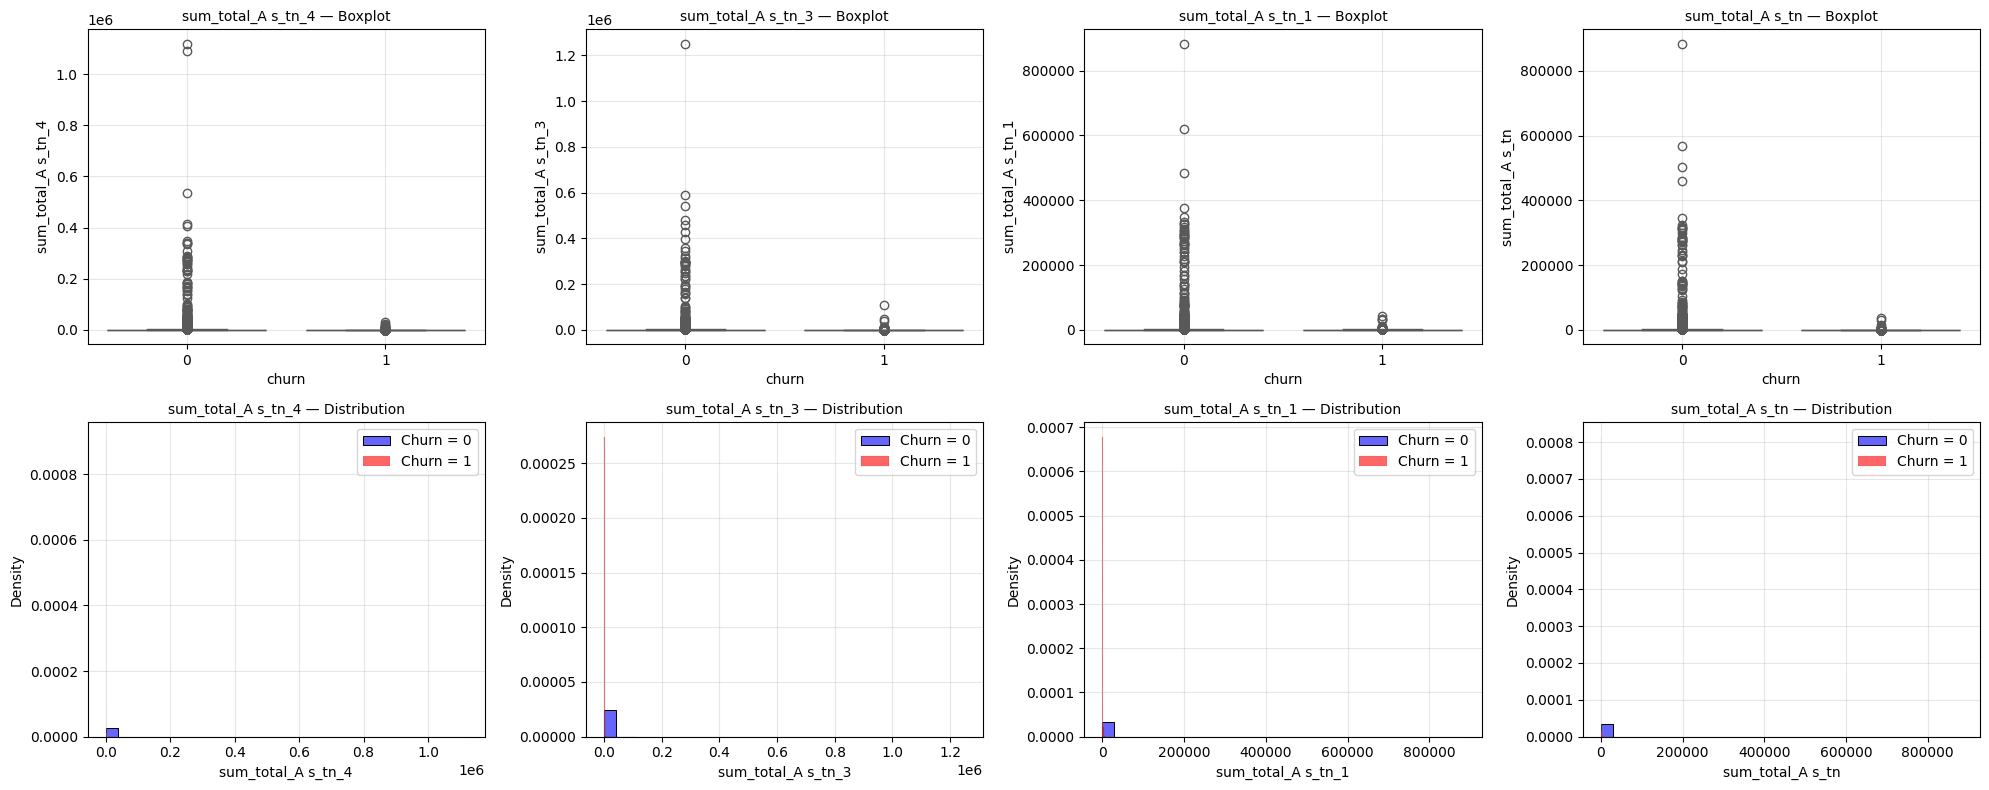

In [9]:
def analyze_numeric_features(features, max_features):
  """
  - features: list features còn lại sau đó lọc tương quan (remaining_features)
  - max_features: số features quan trọng nhất
  """
  if not features:
      print("No numeric features to analyze.")
      return

  print(f"ANALYZING NUMERIC FEATURES and TARGET")
  if 'TOP_PREDICTIVE_FEATURES' in globals():
      analysis_features = [f for f in TOP_PREDICTIVE_FEATURES if f in features][:max_features]
  else:
      # Fix: Assign to analysis_features here as well
      analysis_features = features[:max_features]

  print(f"📊 Analyzing top {len(analysis_features)} numeric features vs {"churn"}")
  print(f"Selected features: {analysis_features}")
  for feature in analysis_features:
      group0 = df[df["churn"] == 0][feature].dropna()
      group1 = df[df["churn"] == 1][feature].dropna()

      # --- Statistical tests ---
      try:
        mw_stat, mw_p = mannwhitneyu(group0, group1, alternative="two-sided")
        ks_stat, ks_p = ks_2samp(group0, group1)

        print(f"\n🔹Feature: {feature}")
        print(f"Mean (0): {group0.mean():.3f}, Std (0): {group0.std():.3f}")
        print(f"Mean (1): {group1.mean():.3f}, Std (1): {group1.std():.3f}")
        print(f"➤ Mann–Whitney p = {mw_p:.3e}")
        print(f"➤ KS test p      = {ks_p:.3e}")

        if mw_p < 0.001:
            print("⭐ Highly significant difference")
        elif mw_p < 0.05:
            print("✔ Statistically significant")
        else:
            print("❌ No significant difference between groups")
      except:
        print(f"\n{feature}: Unable to perform statistical tests")

  # --- Visualization ---
  if analysis_features:
    n_features = len(analysis_features)
    fig, axes = plt.subplots(2, n_features, figsize=(5 * n_features, 8))

    if n_features == 1:
        axes = np.array(axes).reshape(-1, 1)

    for i, feature in enumerate(analysis_features):
      current_ax_boxplot = axes[0][i]
      current_ax_hist = axes[1][i]

      # Boxplot
      sns.boxplot(data=df, x="churn", y=feature, ax=current_ax_boxplot, palette="Set2")
      current_ax_boxplot.set_title(f"{feature} — Boxplot",  fontsize = 10)
      current_ax_boxplot.grid(alpha=0.3)

      # Histogram overlay
      group0 = df[df["churn"] == 0][feature].dropna()
      group1 = df[df["churn"] == 1][feature].dropna()

      sns.histplot(group0, bins=30, alpha=0.6, label="Churn = 0", stat='density', color="blue", ax=current_ax_hist)
      sns.histplot(group1, bins=30, alpha=0.6, label="Churn = 1", stat='density', color="red", ax=current_ax_hist)
      current_ax_hist.set_title(f"{feature} — Distribution", fontsize = 10)
      current_ax_hist.legend()
      current_ax_hist.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

analyze_numeric_features(numeric_features, max_features = 4)

In [10]:
print("=" * 10, "OUTLIER DETECTION (IQR METHOD)", "=" * 10)

TARGET = "churn"

numeric_cols = df_full.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c.lower() not in ["id", TARGET]]

outlier_summary = {}

for col in numeric_cols:
    Q1, Q3 = df_full[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    outlier_count = ((df_full[col] < lower) | (df_full[col] > upper)).sum()
    outlier_summary[col] = outlier_count

summary_df = pd.DataFrame({
    "Feature": list(outlier_summary.keys()),
    "Outlier Count": list(outlier_summary.values())
})
summary_df["Outlier %"] = (summary_df["Outlier Count"] / len(df_full) * 100).round(2)
summary_df = summary_df.sort_values("Outlier Count", ascending=False)

print("Top 20 features with most outliers:")
print(summary_df.head(20))

========== OUTLIER DETECTION (IQR METHOD) ==========
Top 20 features with most outliers:
                       Feature  Outlier Count  Outlier %
12     sum_free_service_fee_tn         250859      27.29
13   sum_free_service_fee_tn_1         244331      26.58
14   sum_free_service_fee_tn_2         243912      26.53
15   sum_free_service_fee_tn_3         241339      26.25
16   sum_free_service_fee_tn_4         240089      26.11
17   sum_free_service_fee_tn_5         238873      25.98
102         sum_E _charge_tn_5         179476      19.52
100         sum_E _charge_tn_3         176560      19.20
98          sum_E _charge_tn_1         173299      18.85
101         sum_E _charge_tn_4         172833      18.80
97            sum_E _charge_tn         172052      18.71
99          sum_E _charge_tn_2         169815      18.47
132          sum_H_charge_tn_5         105697      11.50
127            sum_H_charge_tn         104197      11.33
123           sum_H_times_tn_2         104160      11.33

# 2. Feature Engineering and Processing

In [11]:
print("=" * 10, "FEATURE LEAKAGE DETECTION", "=" * 10)

leakage = []

# A) Suspicious column names
danger_words = ["next", "future", "after", "post", "label", "churn"]
for col in df_full.columns:
    if any(w in col.lower() for w in danger_words):
        leakage.append((col, "Suspicious name pattern"))

# Also remove ID columns
leakage.extend([(col, "Suspicious name pattern") for col in df_full.columns if "ID" in col])

# B) High correlation with target
corr_target = df_full.corr(numeric_only=True)[TARGET].abs()
high_corr = corr_target[corr_target > threshold].index.tolist()

for col in high_corr:
    if col != TARGET:
        leakage.append((col, "Correlation > 0.9 with target"))

# C) Binary identical to target
for col in numeric_cols:
    if df_full[col].nunique() == 2:
        if df_full[col].corr(df_full[TARGET]) > 0.95:
            leakage.append((col, "Binary duplicate of target"))

leakage_df = pd.DataFrame(leakage, columns=["Feature", "Reason"]).drop_duplicates()

print("\n⚠️ Potential leakage features:")
print(leakage_df if not leakage_df.empty else "No leakage found")

print("\n" + "=" * 10, "FILTER REMAINING FEATURES", "=" * 10)

# 1) Remove leakage features
leakage_list = leakage_df["Feature"].tolist() if not leakage_df.empty else []

# 2) Remove highly correlated features among predictors
corr_matrix = df_full[numeric_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop_corr = [
    col for col in upper.columns
    if any(upper[col] > threshold)
]

# 3) Final filtering
final_features = [
    col for col in numeric_cols
    if col not in leakage_list and col not in to_drop_corr
]

print(f"Final usable features: {len(final_features)}")
print(textwrap.fill(', '.join(final_features[:30]), width = 170), "... (truncated)")


========== FEATURE LEAKAGE DETECTION ==========

⚠️ Potential leakage features:
  Feature                   Reason
0   churn  Suspicious name pattern
1      ID  Suspicious name pattern

========== FILTER REMAINING FEATURES ==========
Final usable features: 69
sum_total_use_charge_tn, sum_total_use_charge_tn_1, sum_total_use_charge_tn_2, sum_total_use_charge_tn_3, sum_total_use_charge_tn_4, sum_total_use_charge_tn_5,
sum_total_A s_tn, sum_total_A s_tn_1, sum_total_A s_tn_3, sum_total_A s_tn_4, sum_free_service_fee_tn, sum_t_A_charge_tn, sum_t_A_charge_tn_5, sum_t_dịch vụ B_charge_tn,
sum_t_dịch vụ B_charge_tn_1, sum_t_dịch vụ B_charge_tn_2, sum_t_dịch vụ B_charge_tn_3, sum_t_dịch vụ B_charge_tn_4, sum_t_dịch vụ B_charge_tn_5, sum_t_A _times_tn,
sum_t_A _duration_tn, sum_t_A _duration_tn_1, sum_t_A _duration_tn_2, sum_t_A _duration_tn_3, sum_t_A _duration_tn_4, sum_t_A _duration_tn_5, customer_age,
sum_D_other_charge_tn, sum_D_other_charge_tn_1, sum_D_other_charge_tn_5 ... (truncated)


# 3. Model training and predict

**Model Selection**

In [12]:
# Create train and test sets
print("=" * 10, "DATA PREPARATION FOR MODELING", "=" * 10)

X = df_full[final_features].select_dtypes(include=[np.number]).copy()
y = df_full[TARGET].copy()

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f"Train shape: X = {x_train.shape}, y = {y_train.shape}, churn_rate = {y_train.mean():.4f}")
print(f"Test shape: X = {x_test.shape}, y = {y_test.shape}, churn_rate = {y_test.mean():.4f}")
print(f"Using {len(final_features)} to training models")
print(f"Total churn rate: {y.mean():.4f}")

diff = abs(y_train.mean() - y_test.mean())
print(f"\n1.Train/test churn rate difference: {diff:.4f}")
if diff > 0.01:
    print("❌ Bad split: churn distribution mismatch")
else:
    print("✅ Good split")

# Check missing values
train_missing = x_train.isnull().sum().sum()
test_missing = x_test.isnull().sum().sum()

print("\n2.Check data quality verification...")
print(f"Total missing values in train: {train_missing.sum()}")
print(f"Total missing values in test: {test_missing.sum()}")

def create_preprocessor(features):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

# Create and test procesor
preprocessor = create_preprocessor(final_features) # Pass final_features to the function
print("\n3.Preprocessing pipeline created with:")
print(f"  {len(final_features)} numeric features for scaling") # Updated print statement
print(f"  {len(categorical_features)} categorical features for one-hot encoding")

# Test the preprocessor on a small sample
try:
    x_sample = x_train.head(5)
    x_sample_processed = preprocessor.fit_transform(x_sample) # Changed fit to fit_transform as scaler expects it.
    print(f"✅ Preprocessor test successful. Sample transformed shape: {x_sample_processed.shape}")
except Exception as e:
    print(f"❌ Preprocessor error: {str(e)}")

========== DATA PREPARATION FOR MODELING ==========
Train shape: X = (735488, 69), y = (735488,), churn_rate = 0.0255
Test shape: X = (183873, 69), y = (183873,), churn_rate = 0.0255
Using 69 to training models
Total churn rate: 0.0255

1.Train/test churn rate difference: 0.0000
✅ Good split

2.Check data quality verification...
Total missing values in train: 0
Total missing values in test: 0

3.Preprocessing pipeline created with:
  69 numeric features for scaling
  0 categorical features for one-hot encoding
✅ Preprocessor test successful. Sample transformed shape: (5, 69)


In [13]:
print("=" * 4, "FEATURE SELECTION WITH RANDOM FOREST + CORRELATION", "=" * 4)

# Train Random Forest model
rfc_model = RandomForestClassifier(n_estimators=300,          # KHÔNG quá lớn
    max_depth=12,              # RẤT QUAN TRỌNG
    min_samples_leaf=200,      # tránh overfit + noise
    min_samples_split=500,
    max_features="sqrt",       # chuẩn RF
    class_weight="balanced",   # BẮT BUỘC với churn
    n_jobs=-1, random_state = RANDOM_STATE)

rfc_model.fit(x_train, y_train)

# Extract features importances
importances = pd.Series(rfc_model.feature_importances_, index=x_train.columns).sort_values(ascending=False)
print("Top 15 feature importances: ")
print(importances.head(15))

# Compute correlation matrix with features
corr_matrix = x_train.corr().abs()

# Apply correlation based filtering
selected_features = []
removed_features = set()

for feat in importances.index:  # starting from most important
    if feat not in removed_features:
        selected_features.append(feat)
        # Find features with corr > 0.7 that are not the current feature
        high_corr_feats = [
            f for f in corr_matrix.index
            if f != feat and corr_matrix.loc[f, feat] > 0.9
        ]
        # Add to removal list
        for f in high_corr_feats:
            removed_features.add(f)

final_selected_features = selected_features

print(f"\nFinal selection features: {len(selected_features)}")
print("Examples:", textwrap.fill(', '.join(selected_features[:15])))
print(f"\nFinal selected features: {len(final_selected_features)}")

==== FEATURE SELECTION WITH RANDOM FOREST + CORRELATION ====
Top 15 feature importances: 
sum_total_A s_tn             0.154906
sum_t_A _times_tn            0.099419
sum_t_A _duration_tn         0.086105
sum_G  _times_tn             0.064770
sum_G  _duration_tn          0.056821
sum_C_charge_tn              0.039379
sum_total_use_charge_tn      0.038963
sum_D_other_charge_tn        0.034062
sum_total_A s_tn_1           0.029102
sum_t_A_charge_tn            0.028228
sum_t_dịch vụ B_charge_tn    0.027355
sum_C_times_tn               0.024010
sum_t_A _duration_tn_1       0.020147
sum_total_A s_tn_3           0.018627
sum_t_A _duration_tn_2       0.015527
dtype: float64

Final selection features: 68
Examples: sum_total_A s_tn, sum_t_A _times_tn, sum_t_A _duration_tn, sum_G
_times_tn, sum_G  _duration_tn, sum_C_charge_tn,
sum_total_use_charge_tn, sum_D_other_charge_tn, sum_total_A s_tn_1,
sum_t_A_charge_tn, sum_t_dịch vụ B_charge_tn, sum_C_times_tn, sum_t_A
_duration_tn_1, sum_total_A s_tn_

In [14]:
def create_preprocess_lr():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

def create_preprocess_tree():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median'))
    ])

def build_pipeline(model_name, model):
    if model_name == "LogisticRegression":
        preprocess = create_preprocess_lr()
    else:
        preprocess = create_preprocess_tree()

    return Pipeline([
        ('preprocess', preprocess),
        ('model', model)
    ])


In [15]:
def create_credit_model(model_type, imbalance_type):
    # ---------- MODEL ----------
    if model_type == "LogisticRegression":
        base_param = {
            "max_iter": 300,
            "random_state": RANDOM_STATE,
        }
        if imbalance_type == "CLASS_WEIGHTED":
          base_param["class_weight"] = "balanced"
        model = LogisticRegression(**base_param)

        preprocess = create_preprocess_lr()

    elif model_type == "RandomForest":
        base_param = {
            "random_state": RANDOM_STATE,
            "n_estimators": 100,
            "max_depth": 8,
            "min_samples_leaf": 200,
            "min_samples_split": 500,
            "max_features": "sqrt",
            "n_jobs": -1
        }
        if imbalance_type == "CLASS_WEIGHTED":
          base_param["class_weight"] = "balanced"
        model = RandomForestClassifier(**base_param)

        preprocess = create_preprocess_tree()

    elif model_type == "XGBoost":
        base_param = {
            "n_estimators": 150,
            "eval_metric": "logloss",
            "tree_method": "hist"
        }
        if imbalance_type == "CLASS_WEIGHTED":
          neg, pos = np.bincount(y_train)
          base_param["scale_pos_weight"] = neg / pos
        model = XGBClassifier(**base_param)
        preprocess = create_preprocess_tree()

    elif model_type == "LightGBM":
        base_param = {
          "n_estimators":300,
          "learning_rate":0.05,
          "max_depth":6,
          "num_leaves":31,
          "subsample":0.8,
          "colsample_bytree":0.8,
          "objective":"binary",
          "random_state":RANDOM_STATE,
          "n_jobs":-1
        }
        if imbalance_type == "CLASS_WEIGHTED":
          base_param["class_weight"] = "balanced"
        model = lgb.LGBMClassifier(**base_param)
        preprocess = create_preprocess_tree()
    else:
        raise ValueError(f"Unknown model type: {model_type}")

    # ---------- PIPELINE ----------
    if imbalance_type == "SMOTE":
      if model_type == "LogisticRegression":
          pipeline = ImbPipeline([
              ("imputer", SimpleImputer(strategy="median")),
              ("scaler", StandardScaler()),
              ("smote", SMOTE(random_state=RANDOM_STATE)),
              ("model", model)
          ])
      else:
          pipeline = ImbPipeline([
              ("imputer", SimpleImputer(strategy="median")),
              ("smote", SMOTE(random_state=RANDOM_STATE)),
              ("model", model)
        ])
    else:
      pipeline = Pipeline([
          ("preprocess", preprocess),
          ("model", model)
      ])

    return pipeline

**Model Computation**

In [16]:
@dataclass
class ObtainChurnResult:
  model_name: str
  data_imbalances: str
  accuracy: float
  precision: float
  recall: float
  F1: float
  auc: float
  ks_score: float
  gini: float

def compute_model(model_name, data_imbalances, y_true, y_prob, threshold = 0.5):
  # Comprehensive evaluation for churn model
  y_pred = (y_prob >= threshold).astype(int)

  # Basic metrics
  TN, FP, FN, TP = confusion_matrix(y_true, y_pred).ravel()
  accuracy = accuracy_score(y_true, y_pred)
  precision = precision_score(y_true, y_pred, zero_division = 0)
  recall = recall_score(y_true, y_pred, zero_division = 0)
  F1 = f1_score(y_true, y_pred, zero_division = 0)
  FPR = FP / (FP + TN) if FP + TN > 0 else 0.0
  TPR = TP / (TP + FN) if TP + FN > 0 else 0.0

  # Metric AUC and GINI
  auc = roc_auc_score(y_true, y_prob)
  gini = 2 * auc - 1

  # KS Score
  FPR_CURVE, TPR_CURVE, _ = roc_curve(y_true, y_prob)
  ks_score = max(TPR_CURVE - FPR_CURVE)

  return ObtainChurnResult(model_name, data_imbalances, accuracy, precision,
                           recall, F1, auc, ks_score, gini)

def psi_calculations(expected, actual, bins = 10):
  """
  Calculate Population Stability Index (PSI) with handling for duplicate bin edges
  PSI < 0.1: Stable
  0.1 <= PSI < 0.25: Monitor required
  PSI >= 0.25: Investigate required
  """
  # Define breakpoints using quantiles from the expected distribution
  breakpoints_quantiles = np.linspace(0, 1, bins + 1)
  bin_edges = np.unique(np.quantile(expected, breakpoints_quantiles))

  # Add -inf and inf to cover all values
  bin_edges = np.concatenate([[-np.inf], bin_edges, [np.inf]])

  # Calculate the distribution (counts) for expected and actual data within these bins
  expected_counts = np.histogram(expected, bins=bin_edges)[0]
  actual_counts = np.histogram(actual, bins=bin_edges)[0]

  # Convert counts to percentages
  expected_percent = expected_counts / len(expected)
  actual_percent = actual_counts / len(actual)

  # Add a small constant to zero percentages to avoid log(0) and division by zero
  epsilon = 1e-5
  expected_percent = np.where(expected_percent == 0, epsilon, expected_percent)
  actual_percent = np.where(actual_percent == 0, epsilon, actual_percent)

  # Apply the PSI formula
  psi_value = np.sum((expected_percent - actual_percent) * np.log(expected_percent / actual_percent))
  return psi_value

In [17]:
def capture_rate(y_test, y_pred, ratio):
  cutoff = int(len(y_pred) * ratio)
  df = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred})
  df = df.sort_values('y_pred', ascending=False)
  capture_rate = df.head(cutoff)['y_test'].sum()
  total_churn = df['y_test'].sum()
  return capture_rate / total_churn if total_churn > 0 else np.nan

def find_best_threshold(y_test, y_prob):
  TPR, FPR, thresholds = roc_curve(y_test, y_prob)
  scores = [tpr - fpr for tpr, fpr in zip(TPR, FPR)]
  idx = np.argmax(scores)
  return thresholds[idx]

# Cross-validation function
def cross_validate_model(pipeline, X, y, folds):
  skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=RANDOM_STATE)
  auc, kss = [], []
  for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    pipeline.fit(X_train, y_train)
    y_prob = pipeline.predict_proba(X_test)[:,1]
    # AUC
    auc.append(roc_auc_score(y_test, y_prob))
    # KS
    FPR, TPR, _ = roc_curve(y_test, y_prob)
    ks = max(TPR - FPR)
    kss.append(ks)
  return np.mean(auc), np.mean(kss)

In [18]:
# DEFINE MODELS
BALANCED_DATA = ["NONE", "SMOTE", "CLASS_WEIGHTED"]
MODEL_TYPES = ["LogisticRegression", "RandomForest", "XGBoost", "LightGBM"]
N_SPLITS = 5

print("=" * 5, "TRANING MODEL WITH PSI", "=" * 5)

results = []
all_probs = {} # Initialize all_probs here

# ================================
# RUN CV
# ================================
for balanced_type in BALANCED_DATA:
    for model_name in MODEL_TYPES:
        try:
            print(f"\nTraining {model_name} with {balanced_type}...")

            pipeline = create_credit_model(model_name, balanced_type)

            # Cross-validation (pipeline is refit internally)
            cv_auc, kss = cross_validate_model(
                pipeline, x_train, y_train, N_SPLITS
            )

            # Fit once on full training set for test evaluation
            pipeline.fit(x_train, y_train)

            # Predict
            y_train_prob = pipeline.predict_proba(x_train)[:, 1]
            y_test_prob = pipeline.predict_proba(x_test)[:, 1]

            # Store probabilities for calibration plots
            current_model_config_name = f"{model_name}_{balanced_type}"
            all_probs[current_model_config_name] = y_test_prob

            best_threshold = find_best_threshold(y_train, y_train_prob)
            y_test_pred = (y_test_prob >= best_threshold).astype(int)

            FN = ((y_test_pred == 0) & (y_test == 1)).sum()
            TP = ((y_test_pred == 1) & (y_test == 1)).sum()
            FNR = FN / (FN + TP) if FN + TP > 0 else np.nan

            # PR-AUC
            prec, rec, _ = precision_recall_curve(y_test, y_test_prob)
            pr_auc = auc_calculations(rec, prec)

            psi_value = psi_calculations(y_train_prob, y_test_prob, bins=10)

            result = compute_model(
                model_name, balanced_type, y_test, y_test_prob
            )

            # Brier score loss for training data
            brier = brier_score_loss(y_test, y_test_prob)

            # Capture rates
            capture_5 = capture_rate(y_test, y_test_prob, 0.05)
            capture_10 = capture_rate(y_test, y_test_prob, 0.1)
            capture_20 = capture_rate(y_test, y_test_prob, 0.2)

            res_dict = result.__dict__
            res_dict.update({
                "CV_AUC": cv_auc,
                "KSS": kss,
                "FNR": FNR,
                "PR_AUC": pr_auc,
                "BEST_THRESHOLD": best_threshold,
                "CAPTURE_5": capture_5,
                "CAPTURE_10": capture_10,
                "CAPTURE_20": capture_20,
                "PSI": psi_value,
                "BRIER": brier
            })
            results.append(res_dict)

            print(
                f"➤CV-AUC={cv_auc:.4f}, KSS={kss:.4f}, "
                f"TEST-AUC={result.auc:.4f}, KS={result.ks_score:.4f}, "
                f"PSI={psi_value:.4f}, BRIER={brier:.4f}"
            )
            print(f"➤Capture_5%={capture_5:.2%}, " f"Capture_10%={capture_10:.2%}, " f"Capture_20%={capture_20:.2%}, ")

        except Exception as e:
            print(
                f"❌ Error training {model_name} with {balanced_type}: {e}"
            )

===== TRANING MODEL WITH PSI =====

Training LogisticRegression with NONE...
➤CV-AUC=0.8326, KSS=0.5237, TEST-AUC=0.8336, KS=0.5216, PSI=0.0001, BRIER=0.0209
➤Capture_5%=47.28%, Capture_10%=57.85%, Capture_20%=70.67%, 

Training RandomForest with NONE...
➤CV-AUC=0.8403, KSS=0.5340, TEST-AUC=0.8446, KS=0.5339, PSI=0.0000, BRIER=0.0177
➤Capture_5%=51.82%, Capture_10%=60.21%, Capture_20%=71.78%, 

Training XGBoost with NONE...
➤CV-AUC=0.8593, KSS=0.5785, TEST-AUC=0.8605, KS=0.5810, PSI=0.0001, BRIER=0.0161
➤Capture_5%=57.61%, Capture_10%=66.11%, Capture_20%=75.19%, 

Training LightGBM with NONE...
[LightGBM] [Info] Number of positive: 15026, number of negative: 573364
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.106257 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17187
[LightGBM] [Info] Number of data points in the train set: 588390, number of used features: 69
[LightGBM] [Info] [binary:BoostFrom

========== SUMMARY MODEL ==========


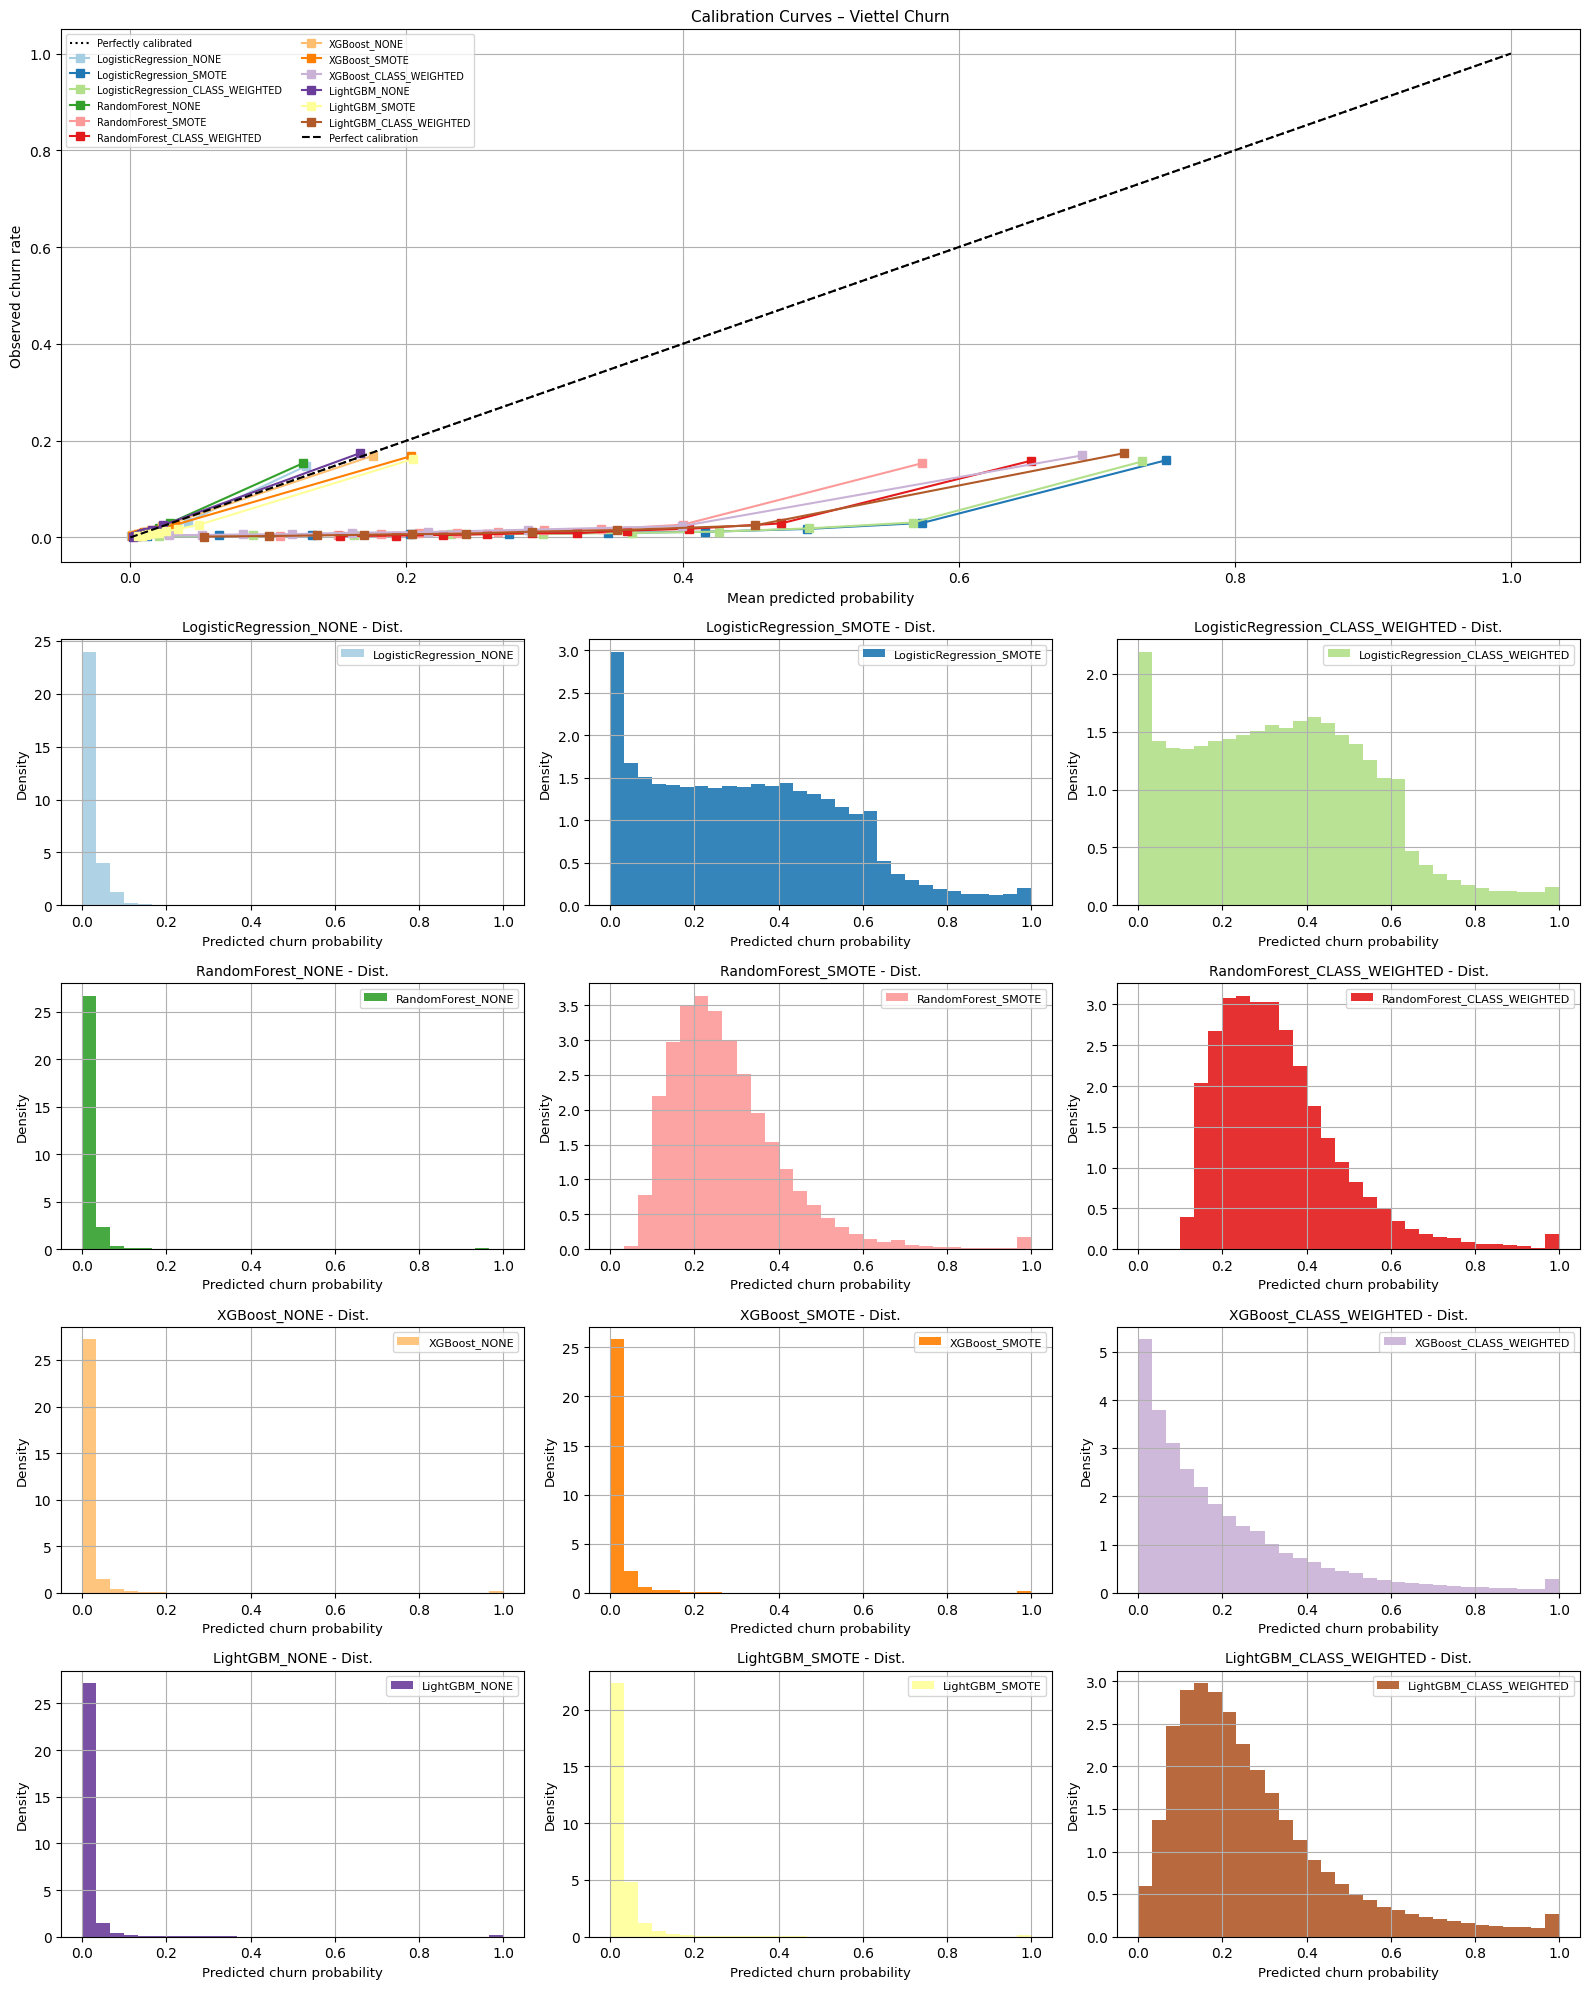

In [19]:
print("=" * 10, "SUMMARY MODEL" ,"=" * 10)

configs = [
    ("LogisticRegression_NONE", "LogisticRegression", "NONE"),
    ("LogisticRegression_SMOTE", "LogisticRegression", "SMOTE"),
    ("LogisticRegression_CLASS_WEIGHTED", "LogisticRegression", "CLASS_WEIGHTED"),

    ("RandomForest_NONE", "RandomForest", "NONE"),
    ("RandomForest_SMOTE", "RandomForest", "SMOTE"),
    ("RandomForest_CLASS_WEIGHTED", "RandomForest", "CLASS_WEIGHTED"),

    ("XGBoost_NONE", "XGBoost", "NONE"),
    ("XGBoost_SMOTE", "XGBoost", "SMOTE"),
    ("XGBoost_CLASS_WEIGHTED", "XGBoost", "CLASS_WEIGHTED"),

    ("LightGBM_NONE", "LightGBM", "NONE"),
    ("LightGBM_SMOTE", "LightGBM", "SMOTE"),
    ("LightGBM_CLASS_WEIGHTED", "LightGBM", "CLASS_WEIGHTED")
]

# Set the number of columns for histogram plots
HIST_N_COLS = 3
# Calculate number of rows needed for histograms
num_hist_rows = (len(configs) + HIST_N_COLS - 1) // HIST_N_COLS

# Adjust GridSpec for one calibration plot at the top and multiple histogram plots below
# Total rows = 1 for calibration + num_hist_rows for histograms
fig = plt.figure(figsize=(16, 4 * (1 + num_hist_rows))) # Adjust figure size dynamically for 3 columns
gs = GridSpec(nrows=1 + num_hist_rows, ncols=HIST_N_COLS, height_ratios=[2] + [1]*num_hist_rows)

ax_cal = fig.add_subplot(gs[0, :]) # Calibration plot spans all columns in the first row
colors = plt.get_cmap("Paired")

# ---------- STORE PROBS FOR HIST ----------
# `all_probs` is already populated from previous execution, no need to re-train models.
# If `all_probs` were not available, the model training for `all_probs` would need to be re-run.

# ---------- CALIBRATION CURVES ----------
for i, (name, model_type, imb) in enumerate(configs):
    # Use pre-computed probabilities from `all_probs`
    y_prob = all_probs[name]

    CalibrationDisplay.from_predictions(
        y_test, # Corrected: y_true should be y_test
        y_prob, # Corrected: y_prob should be the predicted probabilities
        n_bins=10,
        strategy="quantile",   # chuẩn cho churn
        name=name,
        ax=ax_cal,
        color=colors(i),
    )

ax_cal.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax_cal.set_title("Calibration Curves – Viettel Churn", fontsize=11)
ax_cal.set_xlabel("Mean predicted probability")
ax_cal.set_ylabel("Observed churn rate")
ax_cal.legend(fontsize=7, ncol=2)
ax_cal.grid(True)

# ---------- HISTOGRAM ----------
# Generate grid positions for the histograms
# Histograms start from row index 1 (after the calibration plot)
histogram_grid_positions = []
for r in range(1, 1 + num_hist_rows):
    for c in range(HIST_N_COLS):
        if len(histogram_grid_positions) < len(configs): # Ensure we don't go beyond the number of models
            histogram_grid_positions.append((r, c))

for i, (name, _, _) in enumerate(configs):
  if i < len(histogram_grid_positions): # Only plot if a position is available
      row, cols = histogram_grid_positions[i]
      ax_hist_single = fig.add_subplot(gs[row, cols]) # Use a new variable for each histogram axis
      ax_hist_single.hist(all_probs[name], bins=30, range=(0, 1), alpha=0.9,
                  density=True, label=name, color=colors(i))

      ax_hist_single.set_title(f"{name} - Dist.", fontsize=10) # Unique title for each histogram
      ax_hist_single.set_xlabel("Predicted churn probability", fontsize=9.5)
      ax_hist_single.set_ylabel("Density", fontsize=9.5)
      ax_hist_single.legend(fontsize=8)
      ax_hist_single.grid(True)

plt.tight_layout()
plt.show()

In [20]:
IMBALANCE_TYPES = ["CLASS_WEIGHTED", "SMOTE", "NONE"]

def split_model_name(name):
    for imb in IMBALANCE_TYPES:
        suffix = "_" + imb
        if name.endswith(suffix):
            return name[:-len(suffix)], imb
    return name, "UNKNOWN"

In [21]:
print("=" * 8, "EVALUATION METRICS", "=" * 8)

scores = defaultdict(list)

# Create a lookup for CV_AUC from the results list
cv_auc_lookup = {}
for res in results:
    model_config_name = f"{res['model_name']}_{res['data_imbalances']}"
    cv_auc_lookup[model_config_name] = res['CV_AUC']

for name, model_type, imb in configs:
    pipe = create_credit_model(model_type, imb)
    pipe.fit(x_train, y_train)

    y_prob_test = pipe.predict_proba(x_test)[:, 1]
    y_prob_train = pipe.predict_proba(x_train)[:, 1] # Calculate y_train_prob here

    scores["Model"].append(name)
    # Get the pre-calculated CV_AUC from the lookup
    scores["CV-AUC"].append(cv_auc_lookup.get(name, float('nan'))) # Use .get() to handle cases where a key might not be found
    scores["AUC"].append(roc_auc_score(y_test, y_prob_test))
    scores["BRIER"].append(brier_score_loss(y_test, y_prob_test))
    scores["LogLoss"].append(log_loss(y_test, y_prob_test))
    scores["PSI"].append(psi_calculations(y_prob_train, y_prob_test, bins=10))
    scores["GINI"].append(2 * roc_auc_score(y_test, y_prob_test) - 1)
    scores["captures_5%"].append(capture_rate(y_test, y_prob_test, 0.05))
    scores["captures_10%"].append(capture_rate(y_test, y_prob_test, 0.1))
    scores["captures_20%"].append(capture_rate(y_test, y_prob_test, 0.2))

# ============================
# 3. BUILD DATAFRAME
# ============================
score_df = (
    pd.DataFrame(scores)
    .sort_values("AUC", ascending=False)
    .reset_index(drop=True)
)

# ============================
# 4. SPLIT MODEL NAME (FIXED)
# ============================
score_df[["Model_Name", "Imbalance_Type"]] = (
    score_df["Model"]
    .apply(lambda x: pd.Series(split_model_name(x)))
)

# Reorder columns
score_df = score_df[
    ["Model_Name", "Imbalance_Type",
     "CV-AUC", "AUC", "GINI", "BRIER", "LogLoss", "PSI",
     "captures_5%", "captures_10%", "captures_20%"]
]

# Set MultiIndex for reporting
score_df = score_df.set_index(["Model_Name", "Imbalance_Type"])

# ============================
# 5. STYLING WITH GnBu
# ============================
higher_better = [
    "CV-AUC", "AUC", "GINI",
    "captures_5%", "captures_10%", "captures_20%"
]

lower_better = ["BRIER", "LogLoss", "PSI"]

styled_df = (
    score_df.round(4)
    .style
    # higher is better
    .background_gradient(
        cmap="GnBu",
        subset=higher_better,
        axis=0
    )
    # lower is better
    .background_gradient(
        cmap="GnBu_r",
        subset=lower_better,
        axis=0
    )
    .format({
        "captures_5%": "{:.2%}",
        "captures_10%": "{:.2%}",
        "captures_20%": "{:.2%}",
    })
)

display(styled_df)

# ============================
# 6. SUMMARY
# ============================
best_model_name, best_imbalance_type = score_df.index[0]

print("\nTotal model trained:", len(score_df))
print("Best model:", score_df.index[0])
print(f"CV-AUC={cv_auc_lookup.get(f'{best_model_name}_{best_imbalance_type}', float('nan')):.4f}, "
      f"Test-AUC={score_df.loc[score_df.index[0], 'AUC']:.4f}, "
      f"BRIER={score_df.loc[score_df.index[0], 'BRIER']:.4f}, "
      f"LogLoss={score_df.loc[score_df.index[0], 'LogLoss']:.4f}, "
      f"GINI={score_df.loc[score_df.index[0], 'GINI']:.4f}")
print(f"PSI={score_df.loc[score_df.index[0], 'PSI']:.4f}")
print(f"Capture_10%={score_df.loc[score_df.index[0], 'captures_10%']:.2%}")

======== EVALUATION METRICS ========
[LightGBM] [Info] Number of positive: 18782, number of negative: 716706
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.118335 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17211
[LightGBM] [Info] Number of data points in the train set: 735488, number of used features: 69
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.025537 -> initscore=-3.641767
[LightGBM] [Info] Start training from score -3.641767
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 716706, number of negative: 716706
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.248905 seconds.
You can set `force_col_wise=true` to remove the overhead.
[Light


Total model trained: 12
Best model: ('LightGBM', 'NONE')
CV-AUC=0.8783, Test-AUC=0.8813, BRIER=0.0155, LogLoss=0.0708, GINI=0.7626
PSI=0.0000
Capture_10%=68.18%


# 4. ROC Curve for the best training

========== ROC CURVE FOR BEST MODEL TRANING ==========


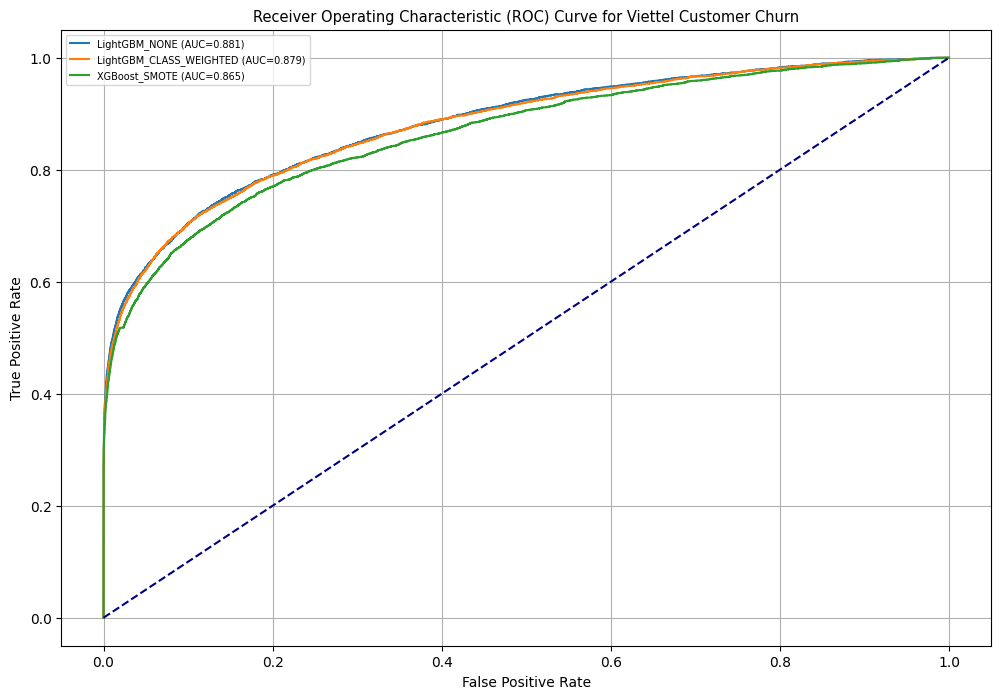

In [22]:
print("=" * 10, "ROC CURVE FOR BEST MODEL TRANING", "=" * 10)

plt.figure(figsize=(12, 8))

top3_models = score_df.sort_values("AUC", ascending=False).head(3).index
top3_keys = [f"{m}_{imb}" for m, imb in top3_models]

for name in top3_keys:
    y_prob = all_probs[name]
    auc_val = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

plt.plot([0, 1], [0, 1], color="navy", lw = 1.5, linestyle = "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve for Viettel Customer Churn", fontsize=10.5)
plt.legend(fontsize = 7)
plt.grid(True)
plt.show()